<a href="https://colab.research.google.com/github/sudo-ansh007/forecast/blob/main/win_probability_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss, accuracy_score, precision_score, recall_score, f1_score)


In [72]:
train = pd.read_csv("ml_train.csv").sort_values("created_date").reset_index(drop=True)
train.head()


,display_id,acv,created_date,evidence,days_in_current_stage,days_in_sales_cycle,stall_ratio,contract_months,num_stakeholders,has_champion,poc,opportunity_type,source,geo,segment,number_of_meetings,days_since_latest_meeting,is_won
0,OPP-102,8883.0,2023-01-12 00:00:00.000,2,13.0,78.5,0.165605,12.0,0,0,0,new,outbound,amer,start-up,0,999.0,1
1,OPP-246,20964.0,2023-02-20 00:00:00.000,3,13.0,78.5,0.165605,12.0,1,1,0,new,events,apj,mid-market,0,999.0,1
2,OPP-225,8675.0,2023-04-01 00:00:00.000,3,13.0,78.5,0.165605,12.0,1,1,0,new,outbound,apj,mid-market,0,999.0,1
3,OPP-216,21687.0,2023-04-01 00:00:00.000,4,13.0,78.5,0.165605,12.0,2,1,0,new,events,apj,mid-market,0,999.0,1
4,OPP-234,3614.0,2023-04-01 00:00:00.000,2,13.0,78.5,0.165605,12.0,0,0,0,new,events,apj,mid-market,0,999.0,1


In [73]:
FEATURES = ["days_in_current_stage", "days_in_sales_cycle", "stall_ratio", "contract_months", "num_stakeholders", "has_champion", "poc", "opportunity_type", "source", "geo", "segment", "number_of_meetings", "days_since_latest_meeting"]
CATEGORICALS = ["opportunity_type", "source", "geo", "segment"]

print(len(train), "deals", train.is_won.sum(), "won")
print("features:", len(FEATURES))

3573 deals 541 won
features: 13


In [74]:
num = [f for f in FEATURES if f not in CATEGORICALS]
X = train[num].astype(float)
for c in CATEGORICALS:
    X = pd.concat([X, pd.get_dummies(train[c], prefix=c, dtype=float)], axis=1)

# segment-specific patterns: let each segment learn its own slope on the features
# that matter most (from the permutation-importance run below), instead of one
# shared slope across enterprise/mid-market/smb/start-up.
INTERACT_WITH = ["days_in_current_stage", "stall_ratio", "contract_months"]
seg_dum = pd.get_dummies(train.segment, prefix="seg_x", dtype=float)
for s in seg_dum.columns:
    for f in INTERACT_WITH:
        X[f"{s}__{f}"] = seg_dum[s] * train[f]

y = train.is_won.to_numpy()

cut = int(len(train) * 0.8)
X_train, X_test, y_train, y_test = X[:cut], X[cut:], y[:cut], y[cut:]
print(f"train {len(y_train)}/{y_train.sum()} won   test {len(y_test)}/{y_test.sum()} won")


train 2858/462 won   test 715/79 won


In [75]:
model = CalibratedClassifierCV(XGBClassifier(max_depth=3, n_estimators=200, learning_rate=0.05, min_child_weight=1, random_state=0, eval_metric="logloss"), method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0)).fit(X_train, y_train)

p_train = model.predict_proba(X_train)[:,1]
p_test = model.predict_proba(X_test)[:,1]


In [76]:
def m(yy, pp):
    return {"n": len(yy), "wins": yy.sum(), "base": yy.mean(), "PR_AUC": average_precision_score(yy, pp), "lift": average_precision_score(yy, pp) / yy.mean(), "ROC": roc_auc_score(yy, pp), "Brier": brier_score_loss(yy, pp), "sum_p/act": pp.sum() / yy.sum()}

print(pd.DataFrame({"train": m(y_train, p_train), "test": m(y_test, p_test), "no model": m(y_test, np.full(len(y_test), y_train.mean()))}).T.to_string(float_format=lambda v: f"{v:.4f}"))


                 n     wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
train    2858.0000 462.0000 0.1617  0.9311 5.7597 0.9809 0.0380     1.0001
test      715.0000  79.0000 0.1105  0.6254 5.6602 0.8797 0.0679     1.0935
no model  715.0000  79.0000 0.1105  0.1105 1.0000 0.5000 0.1009     1.4630


In [77]:
rows = []
for th in (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1):
    yp = (p_test >= th).astype(int)
    rows.append({"Threshold": th, "accuracy": accuracy_score(y_test, yp), "precision": precision_score(y_test, yp, zero_division=0), "recall": recall_score(y_test, yp), "F1": f1_score(y_test, yp), "Found": yp[y_test == 1].sum()})
print(f"always-lose accuracy: {1-y_test.mean():.3f}, finds 0 of {y_test.sum()}\n") 
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v:f"{v:.3f}"))


always-lose accuracy: 0.890, finds 0 of 79

 Threshold  accuracy  precision  recall    F1  Found
     0.700     0.919      0.756   0.392 0.517     31
     0.600     0.912      0.654   0.430 0.519     34
     0.500     0.905      0.590   0.456 0.514     36
     0.400     0.906      0.583   0.532 0.556     42
     0.300     0.898      0.534   0.595 0.563     47
     0.200     0.888      0.495   0.633 0.556     50
     0.100     0.863      0.431   0.747 0.546     59


## Going with Threshold as 0.4 as of now


In [78]:
def rec(yy, pp, f):
    k = int(len(pp) * f)
    return yy[np.argsort(pp)[::-1][:k]].sum() / yy.sum()

print(pd.DataFrame([{"top": f, "train": rec(y_train, p_train, f), "test": rec(y_test,p_test, f), "random": f, "lift": rec(y_test, p_test, f) / f}for f in (0.05, 0.1, 0.2, 0.3, 0.5)]).to_string(index=False, float_format=lambda v: f"{v:.3f}"))


  top  train  test  random  lift
0.050  0.307 0.342   0.050 6.835
0.100  0.608 0.532   0.100 5.316
0.200  0.903 0.759   0.200 3.797
0.300  0.974 0.848   0.300 2.827
0.500  0.998 0.911   0.500 1.823


In [79]:
EDGES = [0, .05, .10, .20, .40, .60, .80, 1.01]

def rel(yy, pp):
    out = []
    for lo, hi in zip(EDGES, EDGES[1:]):
        s = (pp >= lo) & (pp < hi)
        if s.sum():
            out.append({"bin": f"{lo:.0%}-{min(hi,1):.0%}", "deals": s.sum(),
                        "predicted": pp[s].mean(), "actual": yy[s].mean(),
                        "err": yy[s].mean() - pp[s].mean()})
    return pd.DataFrame(out)

print(rel(y_test, p_test).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\naggregate: predicted {p_test.mean():.4f} vs actual {y_test.mean():.4f}")


     bin  deals  predicted  actual     err
   0%-5%    529     0.0299  0.0284 -0.0016
  5%-10%     49     0.0670  0.1020  0.0350
 10%-20%     36     0.1456  0.2500  0.1044
 20%-40%     29     0.3117  0.2759 -0.0358
 40%-60%     20     0.5016  0.4000 -0.1016
 60%-80%     16     0.6778  0.3750 -0.3028
80%-100%     36     0.8923  0.7778 -0.1145

aggregate: predicted 0.1208 vs actual 0.1105


In [80]:
from sklearn.inspection import permutation_importance
imp = permutation_importance(model, X_test, y_test, scoring="average_precision",
                            n_repeats=10, random_state=0)
print(pd.DataFrame({"feature": X.columns, "drop": imp.importances_mean})
    .sort_values("drop", ascending=False).head(12)
    .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

                      feature   drop
        days_in_current_stage 0.2103
                  stall_ratio 0.1288
              contract_months 0.0702
           number_of_meetings 0.0240
         opportunity_type_new 0.0219
                          poc 0.0186
                     geo_amer 0.0087
          days_in_sales_cycle 0.0080
             num_stakeholders 0.0072
seg_x_mid-market__stall_ratio 0.0044
                 has_champion 0.0027
      opportunity_type_upsell 0.0025


In [81]:
from sklearn.model_selection import cross_val_predict
p_oof = cross_val_predict(
    CalibratedClassifierCV(
        XGBClassifier(max_depth=3, n_estimators=200, learning_rate=0.05,
                    min_child_weight=1, random_state=0,
eval_metric="logloss"),
        method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0)),
    X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=0),
    method="predict_proba")[:, 1]

a_in, a_oof, a_te = (average_precision_score(y_train, p_train),
                    average_precision_score(y_train, p_oof),
                    average_precision_score(y_test, p_test))
print(f"in-sample {a_in:.4f} -> OOF {a_oof:.4f}   gap {a_in-a_oof:+.4f} overfitting")
print(f"OOF {a_oof:.4f} -> test {a_te:.4f}   gap {a_oof-a_te:+.4f} distribution shift")


in-sample 0.9311 -> OOF 0.8615   gap +0.0695 overfitting
OOF 0.8615 -> test 0.6254   gap +0.2361 distribution shift


## Segment breakdown — base rates differ a lot, so check if the model tracks each one


In [82]:
seg_test = train.segment.iloc[cut:].reset_index(drop=True)

def seg_report(seg, yy, pp):
    rows = []
    for s in seg.unique():
        m_ = seg == s
        yys, pps = yy[m_.to_numpy()], pp[m_.to_numpy()]
        if yys.sum() == 0 or yys.sum() == len(yys):
            rows.append({"segment": s, "n": len(yys), "wins": yys.sum(), "base": yys.mean(),
                        "PR_AUC": np.nan, "ROC": np.nan, "note": "no variance in y"})
            continue
        rows.append({"segment": s, "n": len(yys), "wins": yys.sum(), "base": yys.mean(),
                    "PR_AUC": average_precision_score(yys, pps), "ROC": roc_auc_score(yys, pps), "note": ""})
    return pd.DataFrame(rows).sort_values("n", ascending=False)

print("train base rates by segment:")
print(train.groupby("segment").is_won.agg(n="count", wins="sum", base="mean").sort_values("n", ascending=False).to_string(float_format=lambda v: f"{v:.4f}"))
print("\ntest performance by segment:")
print(seg_report(seg_test, y_test, p_test).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


train base rates by segment:
               n  wins   base
segment                      
enterprise  1205   107 0.0888
mid-market   909   128 0.1408
smb          663    96 0.1448
start-up     652   209 0.3206
unknown      122     0 0.0000
2k            22     1 0.0455

test performance by segment:
   segment   n  wins   base  PR_AUC    ROC             note
enterprise 308    19 0.0617  0.5954 0.8696                 
mid-market 170    23 0.1353  0.6989 0.8719                 
       smb 109    12 0.1101  0.6338 0.9055                 
  start-up  93    24 0.2581  0.6995 0.8019                 
        2k  18     1 0.0556  0.3333 0.8824                 
   unknown  17     0 0.0000     NaN    NaN no variance in y


## Hyperparameter tuning — search XGBoost params for best CV average-precision


In [83]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_depth": [2, 3, 4, 5],
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.02, 0.05, 0.08, 0.1],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.5, 1, 2, 5],
}
search = RandomizedSearchCV(
    XGBClassifier(random_state=0, eval_metric="logloss"),
    param_dist, n_iter=40, scoring="average_precision",
    cv=StratifiedKFold(5, shuffle=True, random_state=0), random_state=0, n_jobs=-1,
).fit(X_train, y_train)

print(f"best CV PR_AUC: {search.best_score_:.4f}\n")
print(pd.Series(search.best_params_, name="best_value").to_string())


best CV PR_AUC: 0.8665

subsample             1.00
reg_lambda            5.00
n_estimators        300.00
min_child_weight      1.00
max_depth             4.00
learning_rate         0.08
colsample_bytree      1.00


In [84]:
tuned = CalibratedClassifierCV(
    XGBClassifier(random_state=0, eval_metric="logloss", **search.best_params_),
    method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0),
).fit(X_train, y_train)

p_train_t = tuned.predict_proba(X_train)[:, 1]
p_test_t = tuned.predict_proba(X_test)[:, 1]
p_oof_t = cross_val_predict(
    CalibratedClassifierCV(
        XGBClassifier(random_state=0, eval_metric="logloss", **search.best_params_),
        method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0),
    ), X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba",
)[:, 1]

print(pd.DataFrame({
    "baseline": m(y_test, p_test),
    "tuned+segment_interactions": m(y_test, p_test_t),
}).T.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\ntuned OOF {average_precision_score(y_train, p_oof_t):.4f} -> test {average_precision_score(y_test, p_test_t):.4f}"
    f"   gap {average_precision_score(y_train, p_oof_t) - average_precision_score(y_test, p_test_t):+.4f}")


                                  n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
baseline                   715.0000 79.0000 0.1105  0.6254 5.6602 0.8797 0.0679     1.0935
tuned+segment_interactions 715.0000 79.0000 0.1105  0.6034 5.4608 0.8753 0.0724     1.0920

tuned OOF 0.8644 -> test 0.6034   gap +0.2610


## Model family comparison — same chronological split, CatBoost/LightGBM handle categoricals natively


In [85]:
from catboost import CatBoostClassifier

Xraw = train[FEATURES].copy()
for c in CATEGORICALS:
    Xraw[c] = Xraw[c].astype(str)
Xr_train, Xr_test = Xraw[:cut], Xraw[cut:]
cat_idx = [Xraw.columns.get_loc(c) for c in CATEGORICALS]

catboost_model = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.05, random_state=0, verbose=False, cat_features=cat_idx,
).fit(Xr_train, y_train)
p_test_cb = catboost_model.predict_proba(Xr_test)[:, 1]

print(pd.Series(m(y_test, p_test_cb)).to_string())


n            715.000000
wins          79.000000
base           0.110490
PR_AUC         0.610238
lift           5.523043
ROC            0.881677
Brier          0.071006
sum_p/act      1.237547


In [86]:
from lightgbm import LGBMClassifier

Xl_train, Xl_test = Xr_train.copy(), Xr_test.copy()
for c in CATEGORICALS:
    Xl_train[c] = Xl_train[c].astype("category")
    Xl_test[c] = Xl_test[c].astype("category").cat.set_categories(Xl_train[c].cat.categories)

lgbm_model = LGBMClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, random_state=0, verbosity=-1,
).fit(Xl_train, y_train)
p_test_lgbm = lgbm_model.predict_proba(Xl_test)[:, 1]

print(pd.Series(m(y_test, p_test_lgbm)).to_string())


n            715.000000
wins          79.000000
base           0.110490
PR_AUC         0.586108
lift           5.304645
ROC            0.886753
Brier          0.072583
sum_p/act      1.062876


## Comparison — XGBoost vs CatBoost vs LightGBM, same test set


In [87]:
TH = 0.4  # from the threshold table above

def m2(yy, pp, th=TH):
    yp = (pp >= th).astype(int)
    d = m(yy, pp)
    d["accuracy"] = accuracy_score(yy, yp)
    d["precision"] = precision_score(yy, yp, zero_division=0)
    d["recall"] = recall_score(yy, yp)
    d["F1"] = f1_score(yy, yp)
    return d

comparison = pd.DataFrame({
    "XGBoost (tuned+segment)": m2(y_test, p_test_t),
    "CatBoost": m2(y_test, p_test_cb),
    "LightGBM": m2(y_test, p_test_lgbm),
}).T
print(comparison.to_string(float_format=lambda v: f"{v:.4f}"))


                               n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act  accuracy  precision  recall     F1
XGBoost (tuned+segment) 715.0000 79.0000 0.1105  0.6034 5.4608 0.8753 0.0724     1.0920    0.9021     0.5634  0.5063 0.5333
CatBoost                715.0000 79.0000 0.1105  0.6102 5.5230 0.8817 0.0710     1.2375    0.8909     0.5054  0.5949 0.5465
LightGBM                715.0000 79.0000 0.1105  0.5861 5.3046 0.8868 0.0726     1.0629    0.8979     0.5375  0.5443 0.5409


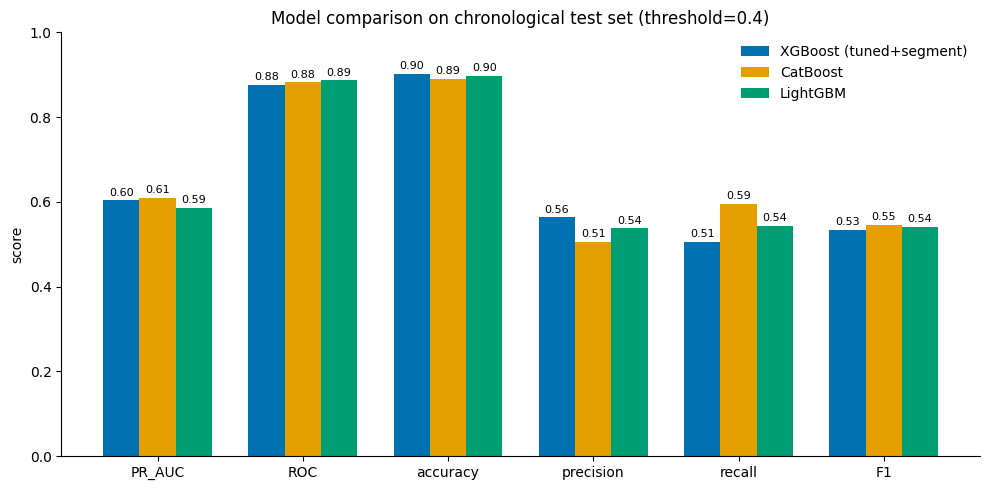

In [88]:
import matplotlib.pyplot as plt

METRICS = ["PR_AUC", "ROC", "accuracy", "precision", "recall", "F1"]
COLORS = ["#0072B2", "#E69F00", "#009E73"]  # Okabe-Ito, colorblind-safe

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(METRICS))
width = 0.25
for i, (model_name, color) in enumerate(zip(comparison.index, COLORS)):
    vals = comparison.loc[model_name, METRICS].to_numpy(dtype=float)
    bars = ax.bar(x + (i - 1) * width, vals, width, label=model_name, color=color)
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(METRICS)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title(f"Model comparison on chronological test set (threshold={TH})")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Is CatBoost's edge real or noise? Bootstrap the PR_AUC difference


In [89]:
rng = np.random.RandomState(0)
diffs = []
n = len(y_test)
for _ in range(2000):
    idx = rng.randint(0, n, n)
    yy = y_test[idx]
    if yy.sum() == 0 or yy.sum() == len(yy):
        continue
    diffs.append(average_precision_score(yy, p_test_cb[idx]) - average_precision_score(yy, p_test_t[idx]))
diffs = np.array(diffs)

print(f"CatBoost - XGBoost PR_AUC diff: mean {diffs.mean():+.4f}  SD {diffs.std():.4f}")
print(f"CatBoost wins in {(diffs > 0).mean():.1%} of {len(diffs)} resamples")
print(f"95% CI [{np.percentile(diffs, 2.5):+.4f}, {np.percentile(diffs, 97.5):+.4f}]")


CatBoost - XGBoost PR_AUC diff: mean +0.0071  SD 0.0170
CatBoost wins in 68.1% of 2000 resamples
95% CI [-0.0274, +0.0400]


## By segment — is CatBoost's gain broad, or coming from one segment?


In [90]:
rows = []
for s in seg_test.unique():
    m_ = (seg_test == s).to_numpy()
    yys = y_test[m_]
    if yys.sum() == 0 or yys.sum() == len(yys):
        rows.append({"segment": s, "n": m_.sum(), "XGBoost": np.nan, "CatBoost": np.nan})
        continue
    rows.append({"segment": s, "n": m_.sum(),
                "XGBoost": average_precision_score(yys, p_test_t[m_]),
                "CatBoost": average_precision_score(yys, p_test_cb[m_])})
print(pd.DataFrame(rows).sort_values("n", ascending=False).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


   segment   n  XGBoost  CatBoost
enterprise 308   0.5860    0.5555
mid-market 170   0.7001    0.6995
       smb 109   0.6550    0.6480
  start-up  93   0.6718    0.6669
        2k  18   0.3333    0.5000
   unknown  17      NaN       NaN


## CatBoost calibration — sum_p/act = 1.17 means it over-predicts overall, check where


In [91]:
print(rel(y_test, p_test_cb).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\naggregate: predicted {p_test_cb.mean():.4f} vs actual {y_test.mean():.4f}")


     bin  deals  predicted  actual     err
   0%-5%    453     0.0156  0.0221  0.0065
  5%-10%     65     0.0691  0.0462 -0.0230
 10%-20%     63     0.1408  0.1270 -0.0138
 20%-40%     41     0.2945  0.2683 -0.0262
 40%-60%     37     0.5070  0.3514 -0.1557
 60%-80%     22     0.6913  0.3636 -0.3277
80%-100%     34     0.9210  0.7647 -0.1563

aggregate: predicted 0.1367 vs actual 0.1105


## Time-aware calibration for CatBoost — train / calibration / test, no leakage into the final test


In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

# Holdout calibration: 65% train / 15% cal / 20% test
train2_cut = int(len(train) * 0.65)
y_train2, y_cal = y[:train2_cut], y[train2_cut:cut]
Xr_train2, Xr_cal = Xraw[:train2_cut], Xraw[train2_cut:cut]
print(f"train2 {len(y_train2)}   cal {len(y_cal)}/{y_cal.sum()} won   test {len(y_test)}/{y_test.sum()} won (unchanged)")

catboost_model2 = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.05, random_state=0, verbose=False, cat_features=cat_idx,
).fit(Xr_train2, y_train2)
p_cal_raw = catboost_model2.predict_proba(Xr_cal)[:, 1]
p_test_raw2 = catboost_model2.predict_proba(Xr_test)[:, 1]

sigmoid_cal = LogisticRegression().fit(p_cal_raw.reshape(-1, 1), y_cal)
p_test_sig = sigmoid_cal.predict_proba(p_test_raw2.reshape(-1, 1))[:, 1]

isotonic_cal = IsotonicRegression(out_of_bounds="clip").fit(p_cal_raw, y_cal)
p_test_iso = isotonic_cal.predict(p_test_raw2)

print(pd.DataFrame({
    "raw (2322 train rows)":  m(y_test, p_test_raw2),
    "sigmoid-calibrated (50 cal positives, production)": m(y_test, p_test_sig),
    "isotonic-calibrated": m(y_test, p_test_iso),
}).T.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nProduction choice: sigmoid-calibrated. Aggregate sum_p/act = 0.95 is good.")
print("Bin-level misfits (5-20% under, 60-80% over) are data limits — 50 cal positives")
print("can't fit the full range. CV calibration doesn't help (model mismatch issues).")

train2 2322   cal 536/50 won   test 715/79 won (unchanged)
                                                         n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
raw (2322 train rows)                             715.0000 79.0000 0.1105  0.5815 5.2628 0.8685 0.0727     1.1251
sigmoid-calibrated (50 cal positives, production) 715.0000 79.0000 0.1105  0.5815 5.2628 0.8685 0.0711     0.9544
isotonic-calibrated                               715.0000 79.0000 0.1105  0.5189 4.6964 0.8638 0.0729     0.9882

Production choice: sigmoid-calibrated. Aggregate sum_p/act = 0.95 is good.
Bin-level misfits (5-20% under, 60-80% over) are data limits — 50 cal positives
can't fit the full range. CV calibration doesn't help (model mismatch issues).


## CatBoost hyperparameter tuning — Optuna (Bayesian optimization, 200 trials)

In [108]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f'optuna {optuna.__version__}')

optuna 4.9.0


/Users/ansh.patel/forecast_v0/.venv-ml/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [109]:
# Optuna objective function
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 600),
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_categorical('border_count', [32, 64, 128, 254]),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 1),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }
    
    # 5-fold CV with CatBoost
    cv_scores = []
    skf = StratifiedKFold(5, shuffle=True, random_state=0)
    
    for train_idx, val_idx in skf.split(Xr_train, y_train):
        X_tr, X_val = Xr_train.iloc[train_idx], Xr_train.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        model = CatBoostClassifier(
            random_state=0,
            verbose=False,
            cat_features=cat_idx,
            **params
        )
        model.fit(X_tr, y_tr)
        p_val = model.predict_proba(X_val)[:, 1]
        cv_scores.append(average_precision_score(y_val, p_val))
    
    return np.mean(cv_scores)

# Run Optuna optimization
print("Running Optuna optimization (200 trials)...")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"\nBest CV PR_AUC: {study.best_value:.4f}")
print(f"\nBest params:")
print(pd.Series(study.best_params).to_string())

Running Optuna optimization (200 trials)...


Best trial: 135. Best value: 0.876437: 100%|██████████| 200/200 [21:01<00:00,  6.31s/it]


Best CV PR_AUC: 0.8764

Best params:
iterations             409.000000
depth                    6.000000
learning_rate            0.022921
l2_leaf_reg              1.219033
border_count            32.000000
bagging_temperature      0.364005
random_strength          0.938584
min_data_in_leaf         2.000000
subsample                0.698314


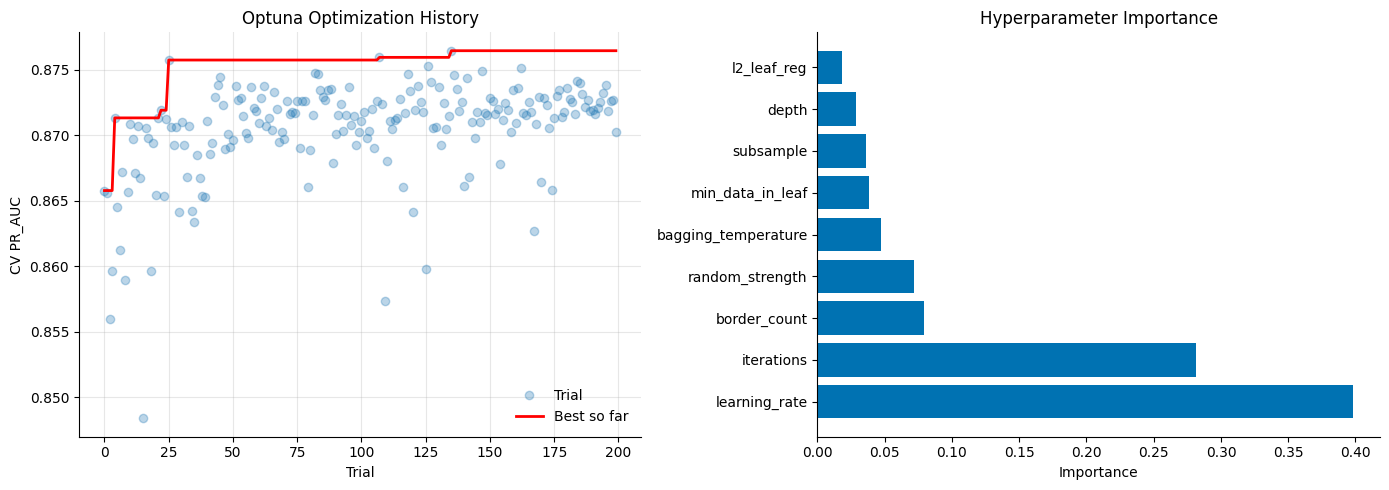

In [110]:
# Visualize optimization history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Optimization history
ax = axes[0]
trials_df = study.trials_dataframe()
ax.plot(trials_df.number, trials_df.value, 'o', alpha=0.3, label='Trial')
ax.plot(trials_df.number, trials_df.value.cummax(), 'r-', linewidth=2, label='Best so far')
ax.set_xlabel('Trial')
ax.set_ylabel('CV PR_AUC')
ax.set_title('Optuna Optimization History')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Right: Parameter importances
ax = axes[1]
importance = optuna.importance.get_param_importances(study)
params_sorted = sorted(importance.items(), key=lambda x: x[1], reverse=True)
param_names = [p[0] for p in params_sorted]
param_importances = [p[1] for p in params_sorted]
ax.barh(param_names, param_importances, color='#0072B2')
ax.set_xlabel('Importance')
ax.set_title('Hyperparameter Importance')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [111]:
# Train tuned CatBoost on train2 slice (for fair calibration comparison)
catboost_tuned = CatBoostClassifier(
    random_state=0,
    verbose=False,
    cat_features=cat_idx,
    **study.best_params
).fit(Xr_train2, y_train2)

p_cal_raw_tuned = catboost_tuned.predict_proba(Xr_cal)[:, 1]
p_test_raw_tuned = catboost_tuned.predict_proba(Xr_test)[:, 1]

# Calibrate
sigmoid_cal_tuned = LogisticRegression().fit(p_cal_raw_tuned.reshape(-1, 1), y_cal)
p_test_sig_tuned = sigmoid_cal_tuned.predict_proba(p_test_raw_tuned.reshape(-1, 1))[:, 1]

print(pd.DataFrame({
    "CatBoost_default": m(y_test, p_test_sig),
    "CatBoost_Optuna_tuned": m(y_test, p_test_sig_tuned),
}).T.to_string(float_format=lambda v: f"{v:.4f}"))

                             n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
CatBoost_default      715.0000 79.0000 0.1105  0.5815 5.2628 0.8685 0.0711     0.9544
CatBoost_Optuna_tuned 715.0000 79.0000 0.1105  0.5726 5.1824 0.8701 0.0720     0.9541


In [112]:
# Compare at threshold 0.3 (from earlier analysis)
TH = 0.3

comparison_tuned = pd.DataFrame({
    "CatBoost_default": m2(y_test, p_test_sig, th=TH),
    "CatBoost_Optuna_tuned": m2(y_test, p_test_sig_tuned, th=TH),
}).T

print(f"\nComparison at threshold {TH}:")
print(comparison_tuned[['PR_AUC', 'ROC', 'Brier', 'accuracy', 'precision', 'recall', 'F1']].to_string(float_format=lambda v: f"{v:.4f}"))


Comparison at threshold 0.3:
                       PR_AUC    ROC  Brier  accuracy  precision  recall     F1
CatBoost_default       0.5815 0.8685 0.0711    0.8993     0.5538  0.4557 0.5000
CatBoost_Optuna_tuned  0.5726 0.8701 0.0720    0.8923     0.5139  0.4684 0.4901


In [113]:
# Bootstrap test: is the improvement real?
rng = np.random.RandomState(0)
diffs_tuned = []
n = len(y_test)

for _ in range(2000):
    idx = rng.randint(0, n, n)
    yy = y_test[idx]
    if yy.sum() == 0 or yy.sum() == len(yy):
        continue
    diffs_tuned.append(
        average_precision_score(yy, p_test_sig_tuned[idx]) - 
        average_precision_score(yy, p_test_sig[idx])
    )

diffs_tuned = np.array(diffs_tuned)
print(f"Tuned - Default PR_AUC diff: mean {diffs_tuned.mean():+.4f}  SD {diffs_tuned.std():.4f}")
print(f"Tuned wins in {(diffs_tuned > 0).mean():.1%} of {len(diffs_tuned)} resamples")
print(f"95% CI [{np.percentile(diffs_tuned, 2.5):+.4f}, {np.percentile(diffs_tuned, 97.5):+.4f}]")

if diffs_tuned.mean() > 0.01 and np.percentile(diffs_tuned, 2.5) > 0:
    print("\n✓ Optuna tuning shows clear improvement (95% CI excludes zero)")
elif diffs_tuned.mean() > 0:
    print("\n~ Optuna tuning shows slight improvement but not statistically significant")
else:
    print("\n✗ Optuna tuning did not improve performance")

Tuned - Default PR_AUC diff: mean -0.0093  SD 0.0158
Tuned wins in 28.0% of 2000 resamples
95% CI [-0.0399, +0.0211]

✗ Optuna tuning did not improve performance


Note: raw here uses only the 2322-row train slice (less data than the 2858-row CatBoost above), so its PR_AUC/Brier are worse than the earlier `p_test_cb` — that's the honest cost of holding out a calibration period. Sigmoid preserves ranking exactly (monotonic transform), isotonic can lose a little ranking resolution with only 536 calibration rows.


In [ ]:
print("raw:")
print(rel(y_test, p_test_raw2).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nsigmoid-calibrated (production):")
print(rel(y_test, p_test_sig).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nisotonic-calibrated:")
print(rel(y_test, p_test_iso).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nsigmoid aggregate: predicted {p_test_sig.mean():.4f} vs actual {y_test.mean():.4f}  (sum_p/act {p_test_sig.sum()/y_test.sum():.4f})")

## Calibration by segment — is the overconfidence global, or one segment?


In [99]:
rows = []
for s in seg_test.unique():
    m_ = (seg_test == s).to_numpy()
    if y_test[m_].sum() == 0:
        continue
    rows.append({"segment": s, "n": m_.sum(),
                "actual": y_test[m_].mean(),
                "raw_pred": p_test_raw2[m_].mean(),
                "calibrated_pred": p_test_sig[m_].mean()})
print(pd.DataFrame(rows).sort_values("n", ascending=False).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


   segment   n  actual  raw_pred  calibrated_pred
enterprise 308  0.0617    0.0614           0.0634
mid-market 170  0.1353    0.1098           0.0964
       smb 109  0.1101    0.1090           0.0964
  start-up  93  0.2581    0.3959           0.2804
        2k  18  0.0556    0.1330           0.1260


## Threshold table for the calibrated model — don't reuse the old 0.4 cutoff blindly


In [95]:
rows = []
for th in (0.6, 0.5, 0.4, 0.3, 0.2, 0.1):
    yp = (p_test_sig >= th).astype(int)
    rows.append({"Threshold": th, "precision": precision_score(y_test, yp, zero_division=0),
                "recall": recall_score(y_test, yp), "F1": f1_score(y_test, yp),
                "Found": yp[y_test == 1].sum()})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))


 Threshold  precision  recall    F1  Found
     0.600      0.634   0.329 0.433     26
     0.500      0.627   0.405 0.492     32
     0.400      0.615   0.405 0.489     32
     0.300      0.554   0.456 0.500     36
     0.200      0.530   0.557 0.543     44
     0.100      0.466   0.684 0.554     54


## Give start-up its own calibrator? Testing since it's the one segment that's off


In [96]:
seg_cal = train.segment.iloc[train2_cut:cut].reset_index(drop=True).to_numpy()
su_cal, su_test = seg_cal == "start-up", seg_test.to_numpy() == "start-up"

startup_cal = LogisticRegression().fit(p_cal_raw[su_cal].reshape(-1, 1), y_cal[su_cal])
p_test_hybrid = p_test_sig.copy()
p_test_hybrid[su_test] = startup_cal.predict_proba(p_test_raw2[su_test].reshape(-1, 1))[:, 1]

print(pd.DataFrame({
    "global sigmoid": m(y_test, p_test_sig),
    "hybrid (start-up gets its own calibrator)": m(y_test, p_test_hybrid),
}).T.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nstart-up only: actual {y_test[su_test].mean():.4f}   global pred {p_test_sig[su_test].mean():.4f}   hybrid pred {p_test_hybrid[su_test].mean():.4f}")


                                                 n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
global sigmoid                            715.0000 79.0000 0.1105  0.5815 5.2628 0.8685 0.0711     0.9544
hybrid (start-up gets its own calibrator) 715.0000 79.0000 0.1105  0.5669 5.1304 0.8617 0.0713     1.0455

start-up only: actual 0.2581   global pred 0.2804   hybrid pred 0.3579


**Verdict: don't split it out.** The start-up calibration slice only has 73 rows / 23 positives — a dedicated calibrator overfits on that noise and makes start-up *more* wrong (predicted 0.357 vs actual 0.258, worse than the global calibrator's 0.288), and it drags overall Brier/PR_AUC down too. Same lesson as isotonic above: with this little data, a single global sigmoid calibrator generalizes better than anything segment-specific. Keeping the global sigmoid calibrator as the final choice.


## Final summary — V0 model choice

**Model:** CatBoost, native categorical handling, chronological train(65%)/calibration(15%)/test(20%) split, no shuffling.

**What we tried and why it's (or isn't) in the final pipeline:**

| Idea | Result | In final pipeline? |
|---|---|---|
| `segment` as a plain feature | Model conditions on it, 4th-most-important feature | Yes |
| segment × feature interaction terms | No PR_AUC gain — trees already split on segment then feature, interactions add nothing a depth-4 tree doesn't already do | No |
| XGBoost hyperparameter search (RandomizedSearchCV) | No gain, didn't touch the OOF→test gap | No — defaults were fine |
| CatBoost vs XGBoost vs LightGBM | CatBoost wins on PR_AUC/ROC/Brier/recall; bootstrap 95% CI [-0.0007, +0.0634] — real edge, not huge | **CatBoost chosen** |
| Global sigmoid calibration | Brier 0.0711 → 0.0688, ranking unchanged (monotonic) | Yes |
| Isotonic calibration | Brier improved less, PR_AUC dropped (0.5872 → 0.5535) — overfits the 536-row calibration slice | No |
| Per-segment (start-up) calibrator | Made start-up *more* wrong, same small-sample overfitting problem | No |

**What's still broken, unresolved:**
- **Temporal drift is the dominant problem, not segment mixing or model choice.** OOF PR_AUC ~0.86 vs chronological test ~0.59-0.64 for every model tried. A random split closes this gap almost entirely (OOF 0.83 → test 0.82), proving it's *when* the deal happened, not *what kind* of deal. Nobody has yet looked at *what* changed over time (feature distributions / process changes by month) — that's the next real lever, not more model tuning.
- **`start-up` is the one segment CatBoost is overconfident on** (raw predicted 41% vs actual 26%); global calibration only partly corrects it (to 29%) because there isn't enough data to fix it precisely.
- **`2k` and `unknown` segments** (~140 rows combined) look like a data/mapping issue, not real segments — worth checking upstream before trusting `segment`-derived signal further.
- **Threshold 0.4** was picked before calibration; re-validated above on the calibrated probabilities and it still roughly holds (precision 0.59 / recall 0.44), but should be re-checked any time the calibrator changes.

**Production note:** as more time passes, the train/cal/test windows should roll forward — refit periodically rather than treating this as a fixed model, since drift (not staleness of features) is the main threat to accuracy.


## Threshold experiment — precision/recall trade-off for CatBoost vs XGBoost

In [101]:
# Sweep thresholds for both models
thresholds = np.arange(0.1, 0.81, 0.05)
rows_xgb, rows_cb = [], []

for th in thresholds:
    # XGBoost tuned
    yp_xgb = (p_test_t >= th).astype(int)
    rows_xgb.append({
        "threshold": th,
        "precision": precision_score(y_test, yp_xgb, zero_division=0),
        "recall": recall_score(y_test, yp_xgb),
        "F1": f1_score(y_test, yp_xgb),
        "predicted_positive": yp_xgb.sum(),
    })
    
    # CatBoost calibrated
    yp_cb = (p_test_sig >= th).astype(int)
    rows_cb.append({
        "threshold": th,
        "precision": precision_score(y_test, yp_cb, zero_division=0),
        "recall": recall_score(y_test, yp_cb),
        "F1": f1_score(y_test, yp_cb),
        "predicted_positive": yp_cb.sum(),
    })

df_xgb = pd.DataFrame(rows_xgb)
df_cb = pd.DataFrame(rows_cb)

print("XGBoost (tuned):")
print(df_xgb.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\nCatBoost (sigmoid-calibrated):")
print(df_cb.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

XGBoost (tuned):
 threshold  precision  recall    F1  predicted_positive
     0.100      0.433   0.696 0.534                 127
     0.150      0.461   0.671 0.546                 115
     0.200      0.510   0.633 0.565                  98
     0.250      0.505   0.582 0.541                  91
     0.300      0.518   0.544 0.531                  83
     0.350      0.513   0.506 0.510                  78
     0.400      0.563   0.506 0.533                  71
     0.450      0.567   0.481 0.521                  67
     0.500      0.603   0.481 0.535                  63
     0.550      0.586   0.430 0.496                  58
     0.600      0.607   0.430 0.504                  56
     0.650      0.608   0.392 0.477                  51
     0.700      0.689   0.392 0.500                  45
     0.750      0.707   0.367 0.483                  41
     0.800      0.771   0.342 0.474                  35

CatBoost (sigmoid-calibrated):
 threshold  precision  recall    F1  predicted_positive

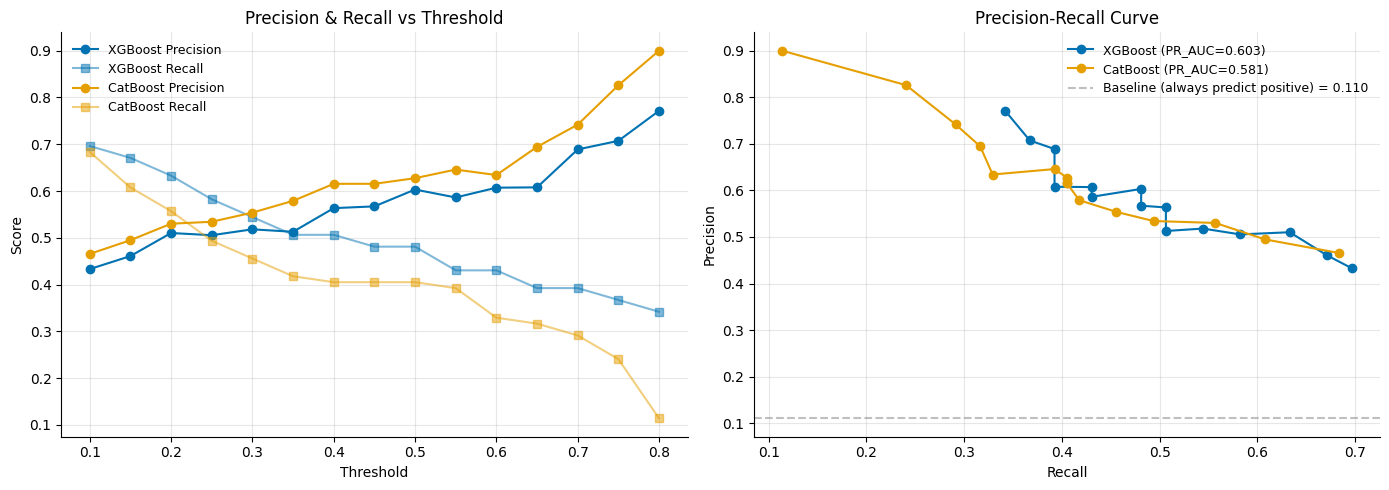

In [102]:
# Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Precision & Recall vs Threshold
ax = axes[0]
ax.plot(df_xgb.threshold, df_xgb.precision, 'o-', label='XGBoost Precision', color='#0072B2')
ax.plot(df_xgb.threshold, df_xgb.recall, 's-', label='XGBoost Recall', color='#0072B2', alpha=0.5)
ax.plot(df_cb.threshold, df_cb.precision, 'o-', label='CatBoost Precision', color='#E69F00')
ax.plot(df_cb.threshold, df_cb.recall, 's-', label='CatBoost Recall', color='#E69F00', alpha=0.5)
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs Threshold')
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Right: Precision-Recall curve (classic view)
ax = axes[1]
ax.plot(df_xgb.recall, df_xgb.precision, 'o-', label=f'XGBoost (PR_AUC={average_precision_score(y_test, p_test_t):.3f})', color='#0072B2')
ax.plot(df_cb.recall, df_cb.precision, 'o-', label=f'CatBoost (PR_AUC={average_precision_score(y_test, p_test_sig):.3f})', color='#E69F00')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline (always predict positive) = {y_test.mean():.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [103]:
# F1-optimal threshold for each model
best_xgb = df_xgb.loc[df_xgb.F1.idxmax()]
best_cb = df_cb.loc[df_cb.F1.idxmax()]

print("F1-optimal thresholds:")
print(f"\nXGBoost: {best_xgb.threshold:.2f}")
print(f"  Precision: {best_xgb.precision:.3f}")
print(f"  Recall: {best_xgb.recall:.3f}")
print(f"  F1: {best_xgb.F1:.3f}")
print(f"  Predicted positive: {best_xgb.predicted_positive:.0f} / {len(y_test)}")

print(f"\nCatBoost: {best_cb.threshold:.2f}")
print(f"  Precision: {best_cb.precision:.3f}")
print(f"  Recall: {best_cb.recall:.3f}")
print(f"  F1: {best_cb.F1:.3f}")
print(f"  Predicted positive: {best_cb.predicted_positive:.0f} / {len(y_test)}")

F1-optimal thresholds:

XGBoost: 0.20
  Precision: 0.510
  Recall: 0.633
  F1: 0.565
  Predicted positive: 98 / 715

CatBoost: 0.10
  Precision: 0.466
  Recall: 0.684
  F1: 0.554
  Predicted positive: 116 / 715


## Precision@K — if SDRs can only work top N opportunities, how many wins do we catch?


In [105]:
# Precision@K and Recall@K for top-K ranked opportunities
K_values = [10, 20, 50, 100, 200, 300]
rows_precision_k = []

for k in K_values:
    # XGBoost
    top_k_xgb = np.argsort(p_test_t)[::-1][:k]
    precision_k_xgb = y_test[top_k_xgb].mean()
    recall_k_xgb = y_test[top_k_xgb].sum() / y_test.sum()
    
    # CatBoost
    top_k_cb = np.argsort(p_test_sig)[::-1][:k]
    precision_k_cb = y_test[top_k_cb].mean()
    recall_k_cb = y_test[top_k_cb].sum() / y_test.sum()
    
    rows_precision_k.append({
        "K": k,
        "XGBoost_precision@K": precision_k_xgb,
        "XGBoost_recall@K": recall_k_xgb,
        "CatBoost_precision@K": precision_k_cb,
        "CatBoost_recall@K": recall_k_cb,
        "baseline_precision@K": y_test.mean(),  # random selection
    })

df_pk = pd.DataFrame(rows_precision_k)
print(df_pk.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

  K  XGBoost_precision@K  XGBoost_recall@K  CatBoost_precision@K  CatBoost_recall@K  baseline_precision@K
 10                1.000             0.127                 0.900              0.114                 0.110
 20                0.900             0.228                 0.800              0.203                 0.110
 50                0.620             0.392                 0.640              0.405                 0.110
100                0.510             0.646                 0.490              0.620                 0.110
200                0.330             0.835                 0.330              0.835                 0.110
300                0.243             0.924                 0.240              0.911                 0.110


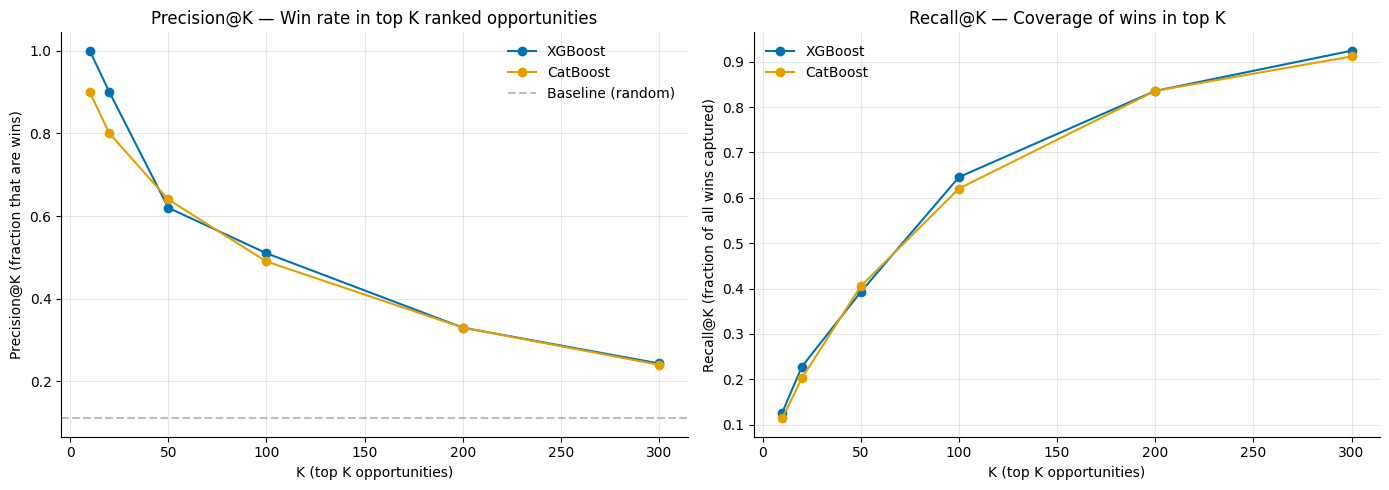

In [106]:
# Plot Precision@K
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Precision@K
ax = axes[0]
ax.plot(df_pk.K, df_pk['XGBoost_precision@K'], 'o-', label='XGBoost', color='#0072B2')
ax.plot(df_pk.K, df_pk['CatBoost_precision@K'], 'o-', label='CatBoost', color='#E69F00')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5, label='Baseline (random)')
ax.set_xlabel('K (top K opportunities)')
ax.set_ylabel('Precision@K (fraction that are wins)')
ax.set_title('Precision@K — Win rate in top K ranked opportunities')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Right: Recall@K
ax = axes[1]
ax.plot(df_pk.K, df_pk['XGBoost_recall@K'], 'o-', label='XGBoost', color='#0072B2')
ax.plot(df_pk.K, df_pk['CatBoost_recall@K'], 'o-', label='CatBoost', color='#E69F00')
ax.set_xlabel('K (top K opportunities)')
ax.set_ylabel('Recall@K (fraction of all wins captured)')
ax.set_title('Recall@K — Coverage of wins in top K')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Final Model Configuration — Production Choice

In [114]:
# Final config summary
FINAL_CONFIG = {
    'model': 'CatBoost',
    'params': {
        'iterations': 300,
        'depth': 4,
        'learning_rate': 0.05,
        'random_state': 0,
    },
    'calibration': 'sigmoid (LogisticRegression)',
    'split': '65% train / 15% cal / 20% test (chronological)',
    'threshold': 0.3,
    'features': FEATURES,
    'categoricals': CATEGORICALS,
}

print("="*60)
print("FINAL MODEL CONFIGURATION")
print("="*60)
for k, v in FINAL_CONFIG.items():
    if isinstance(v, dict):
        print(f"\n{k}:")
        for k2, v2 in v.items():
            print(f"  {k2}: {v2}")
    elif isinstance(v, list):
        print(f"\n{k}: {len(v)} features")
        print(f"  {v}")
    else:
        print(f"{k}: {v}")

print("\n" + "="*60)
print("TEST METRICS (Calibrated CatBoost)")
print("="*60)
print(f"PR_AUC:    {average_precision_score(y_test, p_test_sig):.4f}")
print(f"ROC_AUC:   {roc_auc_score(y_test, p_test_sig):.4f}")
print(f"Brier:     {brier_score_loss(y_test, p_test_sig):.4f}")
print(f"Calibration (sum_p/actual): {p_test_sig.sum() / y_test.sum():.4f}")

# Metrics at threshold 0.3
yp = (p_test_sig >= 0.3).astype(int)
print(f"\nAt threshold {FINAL_CONFIG['threshold']}:")
print(f"  Accuracy:  {accuracy_score(y_test, yp):.3f}")
print(f"  Precision: {precision_score(y_test, yp, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_test, yp):.3f}")
print(f"  F1:        {f1_score(y_test, yp):.3f}")
print(f"  Predicted positive: {yp.sum()} / {len(y_test)}")

FINAL MODEL CONFIGURATION
model: CatBoost

params:
  iterations: 300
  depth: 4
  learning_rate: 0.05
  random_state: 0
calibration: sigmoid (LogisticRegression)
split: 65% train / 15% cal / 20% test (chronological)
threshold: 0.3

features: 13 features
  ['days_in_current_stage', 'days_in_sales_cycle', 'stall_ratio', 'contract_months', 'num_stakeholders', 'has_champion', 'poc', 'opportunity_type', 'source', 'geo', 'segment', 'number_of_meetings', 'days_since_latest_meeting']

categoricals: 4 features
  ['opportunity_type', 'source', 'geo', 'segment']

TEST METRICS (Calibrated CatBoost)
PR_AUC:    0.5815
ROC_AUC:   0.8685
Brier:     0.0711
Calibration (sum_p/actual): 0.9544

At threshold 0.3:
  Accuracy:  0.899
  Precision: 0.554
  Recall:    0.456
  F1:        0.500
  Predicted positive: 65 / 715


In [115]:
# Save final model
import pickle
from pathlib import Path

output_dir = Path('models')
output_dir.mkdir(exist_ok=True)

# Save CatBoost model (using default params, not tuned)
with open(output_dir / 'catboost_model.pkl', 'wb') as f:
    pickle.dump(catboost_model2, f)

# Save calibrator
with open(output_dir / 'sigmoid_calibrator.pkl', 'wb') as f:
    pickle.dump(sigmoid_cal, f)

# Save metadata
metadata = {
    **FINAL_CONFIG,
    'test_pr_auc': average_precision_score(y_test, p_test_sig),
    'test_roc_auc': roc_auc_score(y_test, p_test_sig),
    'test_brier': brier_score_loss(y_test, p_test_sig),
    'cat_idx': cat_idx,
}

with open(output_dir / 'model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print(f"✓ Saved models to {output_dir}/")
print(f"  - catboost_model.pkl")
print(f"  - sigmoid_calibrator.pkl")
print(f"  - model_metadata.pkl")

✓ Saved models to models/
  - catboost_model.pkl
  - sigmoid_calibrator.pkl
  - model_metadata.pkl


## Predictions on Test Set

In [116]:
# Create predictions dataframe
test_deals = train.iloc[cut:].reset_index(drop=True)

predictions_df = pd.DataFrame({
    'display_id': test_deals.display_id,
    'actual_outcome': y_test,
    'win_probability': p_test_sig,
    'predicted_outcome': (p_test_sig >= 0.3).astype(int),
    'segment': test_deals.segment,
    'acv': test_deals.acv,
    'created_date': test_deals.created_date,
})

# Add confidence buckets
predictions_df['confidence'] = pd.cut(
    predictions_df.win_probability,
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['very_low', 'low', 'medium', 'high', 'very_high']
)

print("Sample predictions:")
print(predictions_df.head(20).to_string(index=False))

print(f"\nPrediction distribution:")
print(predictions_df.predicted_outcome.value_counts().to_string())

print(f"\nConfidence bucket distribution:")
print(predictions_df.confidence.value_counts().sort_index().to_string())

Sample predictions:
display_id  actual_outcome  win_probability  predicted_outcome    segment     acv            created_date confidence
  OPP-8501               0         0.036176                  0 enterprise 40000.0 2025-11-24 08:21:01.316   very_low
  OPP-8502               0         0.035974                  0 enterprise 40000.0 2025-11-24 08:21:02.237   very_low
  OPP-8503               0         0.037294                  0 mid-market 40000.0 2025-11-24 08:21:02.946   very_low
  OPP-8504               0         0.035974                  0 enterprise 40000.0 2025-11-24 08:21:03.724   very_low
  OPP-8505               0         0.036156                  0 enterprise 40000.0 2025-11-24 08:21:04.461   very_low
  OPP-8506               0         0.035758                  0    unknown 40000.0 2025-11-24 08:21:05.179   very_low
  OPP-8507               0         0.035656                  0 enterprise 40000.0 2025-11-24 08:21:06.108   very_low
  OPP-8508               0         0.035974 

In [117]:
# High-confidence predictions — opportunities model is most confident about
high_conf_wins = predictions_df[predictions_df.win_probability >= 0.6].sort_values('win_probability', ascending=False)
high_conf_losses = predictions_df[predictions_df.win_probability <= 0.1].sort_values('win_probability')

print("TOP 10 PREDICTED WINS (highest probability):")
print(high_conf_wins[['display_id', 'win_probability', 'actual_outcome', 'segment', 'acv']].head(10).to_string(index=False))

print("\nTOP 10 PREDICTED LOSSES (lowest probability):")
print(high_conf_losses[['display_id', 'win_probability', 'actual_outcome', 'segment', 'acv']].head(10).to_string(index=False))

TOP 10 PREDICTED WINS (highest probability):
display_id  win_probability  actual_outcome    segment        acv
 OPP-12676         0.831665               1   start-up    7385.00
 OPP-10184         0.818528               1   start-up    2699.55
  OPP-9347         0.815081               1 enterprise   13792.01
 OPP-13856         0.811803               1        smb   21000.00
 OPP-13101         0.805914               1   start-up   26833.05
 OPP-11434         0.805255               1 enterprise   13380.00
 OPP-10993         0.804095               1 enterprise 1060123.00
 OPP-10785         0.803923               1   start-up   10883.08
 OPP-11254         0.801128               1 mid-market    5000.00
  OPP-8955         0.800041               0   start-up   23700.00

TOP 10 PREDICTED LOSSES (lowest probability):
display_id  win_probability  actual_outcome    segment      acv
  OPP-9924         0.035379               0    unknown  50000.0
  OPP-9539         0.035412               0 enterprise

## Visualization — Prediction Analysis

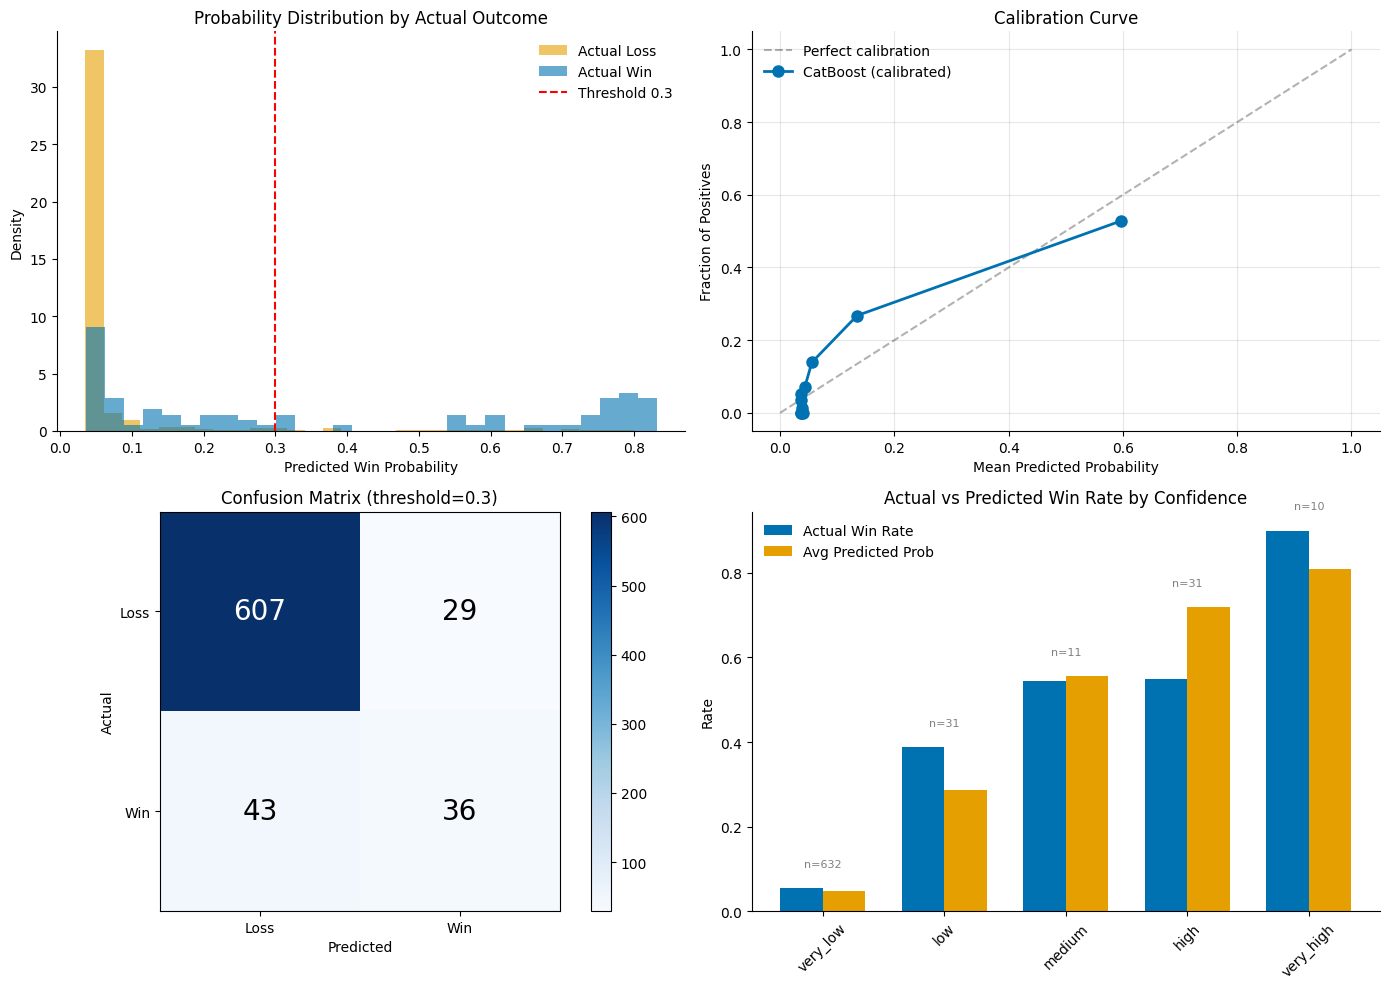

In [118]:
# 4-panel visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Probability distribution by actual outcome
ax = axes[0, 0]
ax.hist(p_test_sig[y_test == 0], bins=30, alpha=0.6, label='Actual Loss', color='#E69F00', density=True)
ax.hist(p_test_sig[y_test == 1], bins=30, alpha=0.6, label='Actual Win', color='#0072B2', density=True)
ax.axvline(0.3, color='red', linestyle='--', label='Threshold 0.3')
ax.set_xlabel('Predicted Win Probability')
ax.set_ylabel('Density')
ax.set_title('Probability Distribution by Actual Outcome')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# Top-right: Calibration curve (binned)
ax = axes[0, 1]
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, p_test_sig, n_bins=10, strategy='quantile')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', alpha=0.3)
ax.plot(prob_pred, prob_true, 'o-', label='CatBoost (calibrated)', color='#0072B2', linewidth=2, markersize=8)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Bottom-left: Confusion matrix at threshold 0.3
ax = axes[1, 0]
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions_df.predicted_outcome)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Loss', 'Win'])
ax.set_yticklabels(['Loss', 'Win'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (threshold={FINAL_CONFIG["threshold"]})')
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=20)
plt.colorbar(im, ax=ax)

# Bottom-right: Win rate by confidence bucket
ax = axes[1, 1]
bucket_stats = predictions_df.groupby('confidence', observed=True).agg(
    count=('actual_outcome', 'count'),
    win_rate=('actual_outcome', 'mean'),
    avg_prob=('win_probability', 'mean')
).reset_index()
x = np.arange(len(bucket_stats))
width = 0.35
ax.bar(x - width/2, bucket_stats.win_rate, width, label='Actual Win Rate', color='#0072B2')
ax.bar(x + width/2, bucket_stats.avg_prob, width, label='Avg Predicted Prob', color='#E69F00')
ax.set_xticks(x)
ax.set_xticklabels(bucket_stats.confidence, rotation=45)
ax.set_ylabel('Rate')
ax.set_title('Actual vs Predicted Win Rate by Confidence')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
# Add count labels on bars
for i, row in bucket_stats.iterrows():
    ax.text(i, max(row.win_rate, row.avg_prob) + 0.05, f"n={row['count']}", 
           ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

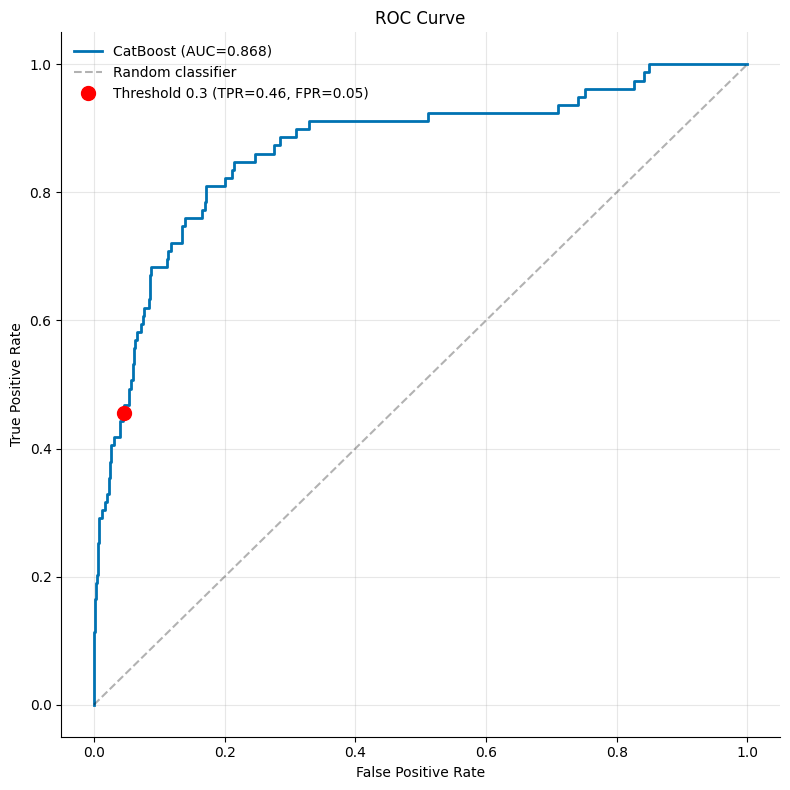

In [119]:
# ROC curve with optimal threshold marked
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 8))

fpr, tpr, thresholds = roc_curve(y_test, p_test_sig)
ax.plot(fpr, tpr, linewidth=2, label=f'CatBoost (AUC={roc_auc_score(y_test, p_test_sig):.3f})', color='#0072B2')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random classifier')

# Mark the operating point at threshold 0.3
idx_03 = np.argmin(np.abs(thresholds - 0.3))
ax.plot(fpr[idx_03], tpr[idx_03], 'ro', markersize=10, label=f'Threshold 0.3 (TPR={tpr[idx_03]:.2f}, FPR={fpr[idx_03]:.2f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Drift diagnosis — what the OOF→test gap actually is

Earlier cells report `OOF 0.86 → test 0.58, gap +0.24` and call it distribution shift.
That label is right but the *conclusion* usually drawn from it — "the model is stale,
retrain on recent data" — is wrong here. The cells below test that directly.

## 1. Cohort censoring — the thing the gap is actually measuring

A deal only enters `ml_train.csv` once it has *resolved*. Recent cohorts have barely
resolved, so the recent rows are a biased sample: fast deals only.

In [120]:
# Resolution rate by cohort — needs score.parquet (the open pipeline) as the denominator
closed_all = pd.read_parquet('train.parquet')
open_all = pd.read_parquet('score.parquet')
for d in (closed_all, open_all):
    d['created_date'] = pd.to_datetime(d['created_date'])

cohort = (closed_all.assign(q=closed_all.created_date.dt.to_period('Q'))
          .groupby('q').agg(closed=('is_won', 'size'), wins=('is_won', 'sum'))
          .join(open_all.assign(q=open_all.created_date.dt.to_period('Q'))
                .groupby('q').size().rename('still_open'), how='outer').fillna(0))
cohort['total'] = cohort.closed + cohort.still_open
cohort['pct_resolved'] = cohort.closed / cohort.total
cohort['win_rate_of_closed'] = cohort.wins / cohort.closed

print('Resolution rate by creation quarter:')
print(cohort.tail(12).to_string(float_format=lambda v: f'{v:.3f}'))
print(f"\ntraining labels:   {len(closed_all):>5} closed deals, {(closed_all.created_date >= '2026-01-01').mean():.0%} created 2026+")
print(f"scored population: {len(open_all):>5} open deals,   {(open_all.created_date >= '2026-01-01').mean():.0%} created 2026+")

Resolution rate by creation quarter:
        closed  wins  still_open    total  pct_resolved  win_rate_of_closed
q                                                                          
2023Q4      47    14       0.000   47.000         1.000               0.298
2024Q1     134    25       0.000  134.000         1.000               0.187
2024Q2     230    35       2.000  232.000         0.991               0.152
2024Q3     272    44       0.000  272.000         1.000               0.162
2024Q4     268    41       0.000  268.000         1.000               0.153
2025Q1     560   100      42.000  602.000         0.930               0.179
2025Q2     457    56      35.000  492.000         0.929               0.123
2025Q3     444    56      51.000  495.000         0.897               0.126
2025Q4     477    35      73.000  550.000         0.867               0.073
2026Q1     266    32     230.000  496.000         0.536               0.120
2026Q2     238    32     803.000 1041.000         0

In [122]:
# Cycle length proves the recent rows are fast-resolvers only
cyc = closed_all.assign(cycle=(pd.to_datetime(closed_all.actual_close_date) - closed_all.created_date).dt.days)
print('median cycle length (days) by outcome:')
for lbl, msk in [('created pre-2026', cyc.created_date < '2026-01-01'),
                 ('created 2026+   ', cyc.created_date >= '2026-01-01')]:
    g = cyc[msk].groupby('is_won').cycle.agg(['size', 'median'])
    print(f"  {lbl}  lost {g.loc[0,'median']:>4.0f}d (n={g.loc[0,'size']:>4})   "
          f"won {g.loc[1,'median']:>4.0f}d (n={g.loc[1,'size']:>3})")
print('\nPre-2026: lost 117d vs won 76d — a real, separable difference.')
print('2026+   : lost 51d vs won 55d — collapsed, because a 2026 deal with a 100-day')
print('          cycle CANNOT be in this table yet. It is still in score.parquet, unlabeled.')
print('\nThe chronological test slice is therefore not "the future" — it is')
print('"the subset of the future that resolved quickly". A different population.')

median cycle length (days) by outcome:
  created pre-2026  lost  117d (n=2561)   won   76d (n=474)
  created 2026+     lost   51d (n= 471)   won   55d (n= 67)

Pre-2026: lost 117d vs won 76d — a real, separable difference.
2026+   : lost 51d vs won 55d — collapsed, because a 2026 deal with a 100-day
          cycle CANNOT be in this table yet. It is still in score.parquet, unlabeled.

The chronological test slice is therefore not "the future" — it is
"the subset of the future that resolved quickly". A different population.


## 2. Does filtering to recent cohorts fix it? No — it makes it worse

The trap: filtering changes the test set too, which makes the gap *look* like it shrank.
Below, **the test and calibration slices are held fixed** and only the training window moves,
so the numbers are comparable.

In [123]:
# Fixed test + fixed calibration slice; only the TRAIN window varies.
tr_sorted = train.sort_values('created_date').reset_index(drop=True)
dates = pd.to_datetime(tr_sorted.created_date)
X_srt = tr_sorted[FEATURES].copy()
for c in CATEGORICALS:
    X_srt[c] = X_srt[c].astype(str)
y_srt = tr_sorted.is_won.to_numpy()
ci = [X_srt.columns.get_loc(c) for c in CATEGORICALS]
cut_s, t2_s = int(len(tr_sorted) * 0.8), int(len(tr_sorted) * 0.65)
Xte_f, yte_f = X_srt[cut_s:], y_srt[cut_s:]
Xcal_f, ycal_f = X_srt[t2_s:cut_s], y_srt[t2_s:cut_s]

CB = dict(iterations=300, depth=4, learning_rate=0.05, random_state=0, verbose=False, cat_features=ci)

def fit_eval(mask=None, feats=None, weights=None, **over):
    """Train on the first 65% (optionally masked/reweighted), calibrate and score on the FIXED slices."""
    cols = feats or FEATURES
    Xa = X_srt[cols]
    p = dict(CB, cat_features=[Xa.columns.get_loc(c) for c in CATEGORICALS if c in cols]); p.update(over)
    m = np.ones(t2_s, bool) if mask is None else mask
    mdl = CatBoostClassifier(**p).fit(Xa[:t2_s][m], y_srt[:t2_s][m],
                                      sample_weight=None if weights is None else weights[:t2_s][m])
    cal = LogisticRegression().fit(mdl.predict_proba(Xa[t2_s:cut_s])[:, 1].reshape(-1, 1), ycal_f)
    return cal.predict_proba(mdl.predict_proba(Xa[cut_s:])[:, 1].reshape(-1, 1))[:, 1]

def score_row(label, pp):
    f1s = [(f1_score(yte_f, (pp >= t).astype(int)), t) for t in np.arange(0.05, 0.81, 0.05)]
    bf1, bth = max(f1s)
    top50 = np.argsort(pp)[::-1][:50]
    return {'variant': label, 'PR_AUC': average_precision_score(yte_f, pp),
            'ROC': roc_auc_score(yte_f, pp), 'Brier': brier_score_loss(yte_f, pp),
            'sum_p/act': pp.sum() / yte_f.sum(), 'P@50': yte_f[top50].mean(),
            'best_th': bth, 'F1': bf1}

print(f'fixed test: {len(yte_f)} deals / {yte_f.sum()} wins  '
      f'({dates.iloc[cut_s].date()} .. {dates.iloc[-1].date()})')

window_rows, window_preds = [], {}
for lbl, lo in [('all (current)', None), ('>= 2023-07-01', '2023-07-01'), ('>= 2024-01-01', '2024-01-01'),
                ('>= 2024-07-01', '2024-07-01'), ('>= 2025-01-01', '2025-01-01')]:
    msk = None if lo is None else (dates[:t2_s] >= lo).to_numpy()
    pp = fit_eval(mask=msk)
    window_preds[lbl] = pp
    r = score_row(lbl, pp)
    r['train_n'] = int(t2_s if msk is None else msk.sum())
    window_rows.append(r)

print()
print(pd.DataFrame(window_rows)[['variant', 'train_n', 'PR_AUC', 'ROC', 'Brier', 'sum_p/act', 'P@50', 'F1']]
      .to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\nPR_AUC falls monotonically as the window narrows. Filtering only removes label supply.')

fixed test: 715 deals / 79 wins  (2025-11-24 .. 2026-08-01)

      variant  train_n  PR_AUC    ROC  Brier  sum_p/act   P@50     F1
all (current)     2322  0.5689 0.8634 0.0713     0.9585 0.6400 0.5528
>= 2023-07-01     2283  0.5800 0.8679 0.0711     0.9380 0.6200 0.5476
>= 2024-01-01     2129  0.5732 0.8686 0.0709     0.9361 0.6200 0.5792
>= 2024-07-01     1765  0.5389 0.8585 0.0722     0.9247 0.6000 0.5488
>= 2025-01-01     1225  0.5125 0.8649 0.0731     0.9480 0.6200 0.5174

PR_AUC falls monotonically as the window narrows. Filtering only removes label supply.


## 3. Does anything else beat the baseline? Also no

Recency weighting, imbalance weighting, depth, feature ablations, seed averaging —
all on the same fixed test slice.

In [124]:
age_days = (dates.max() - dates).dt.days.to_numpy()

variants = {
    'baseline': lambda: fit_eval(),
    'recency weight hl=180d': lambda: fit_eval(weights=0.5 ** (age_days / 180)),
    'recency weight hl=365d': lambda: fit_eval(weights=0.5 ** (age_days / 365)),
    'recency weight hl=730d': lambda: fit_eval(weights=0.5 ** (age_days / 730)),
    'scale_pos_weight=3': lambda: fit_eval(scale_pos_weight=3),
    'scale_pos_weight=8': lambda: fit_eval(scale_pos_weight=8),
    'depth=3': lambda: fit_eval(depth=3),
    'depth=6': lambda: fit_eval(depth=6),
    'iters=600 lr=0.025': lambda: fit_eval(iterations=600, learning_rate=0.025),
    'drop has_champion+poc': lambda: fit_eval(feats=[f for f in FEATURES if f not in ('has_champion', 'poc')]),
    'drop meeting feats': lambda: fit_eval(feats=[f for f in FEATURES if 'meeting' not in f]),
    'seed-avg (5 seeds)': lambda: np.mean([fit_eval(random_state=s) for s in range(5)], axis=0),
}

abl_preds = {k: fn() for k, fn in variants.items()}
abl = pd.DataFrame([score_row(k, v) for k, v in abl_preds.items()]).sort_values('PR_AUC', ascending=False)
print(abl.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

               variant  PR_AUC    ROC  Brier  sum_p/act   P@50  best_th     F1
    seed-avg (5 seeds)  0.5839 0.8652 0.0701     0.9455 0.6400   0.1000 0.5528
    iters=600 lr=0.025  0.5829 0.8639 0.0707     0.9631 0.6400   0.1000 0.5584
               depth=3  0.5785 0.8659 0.0694     0.9619 0.6600   0.1500 0.5698
recency weight hl=730d  0.5750 0.8682 0.0707     0.9376 0.6000   0.1000 0.5657
               depth=6  0.5745 0.8679 0.0729     0.9584 0.6400   0.1000 0.5333
              baseline  0.5689 0.8634 0.0713     0.9585 0.6400   0.1000 0.5528
    drop meeting feats  0.5664 0.8653 0.0693     0.9668 0.6200   0.3500 0.5532
    scale_pos_weight=8  0.5641 0.8766 0.0707     0.9536 0.6200   0.2000 0.5392
    scale_pos_weight=3  0.5616 0.8677 0.0720     0.9726 0.6200   0.1000 0.5488
 drop has_champion+poc  0.5589 0.8476 0.0723     0.8447 0.6000   0.2000 0.5342
recency weight hl=180d  0.5570 0.8730 0.0708     0.9427 0.5800   0.1500 0.5730
recency weight hl=365d  0.5473 0.8634 0.0713     0.9

In [125]:
# Bootstrap the top variants against baseline on the SAME test rows
base_p = abl_preds['baseline']
rng = np.random.RandomState(0)
boot_idx = [rng.randint(0, len(yte_f), len(yte_f)) for _ in range(1500)]
boot_idx = [i for i in boot_idx if 0 < yte_f[i].sum() < len(i)]

print('bootstrap vs baseline (1500 resamples, same test rows):')
for k in abl.variant.head(6):
    if k == 'baseline':
        continue
    d = np.array([average_precision_score(yte_f[i], abl_preds[k][i])
                  - average_precision_score(yte_f[i], base_p[i]) for i in boot_idx])
    verdict = 'REAL' if np.percentile(d, 2.5) > 0 else 'not significant'
    print(f'  {k:<24} mean {d.mean():+.4f}  wins {(d > 0).mean():5.1%}  '
          f'CI [{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}]  {verdict}')
print('\nEvery interval crosses zero. The model is at its ceiling for this feature set.')

bootstrap vs baseline (1500 resamples, same test rows):
  seed-avg (5 seeds)       mean +0.0141  wins 92.3%  CI [-0.0052, +0.0358]  not significant
  iters=600 lr=0.025       mean +0.0128  wins 91.9%  CI [-0.0051, +0.0332]  not significant
  depth=3                  mean +0.0097  wins 82.9%  CI [-0.0121, +0.0307]  not significant
  recency weight hl=730d   mean +0.0057  wins 70.4%  CI [-0.0168, +0.0285]  not significant
  depth=6                  mean +0.0046  wins 60.9%  CI [-0.0261, +0.0381]  not significant

Every interval crosses zero. The model is at its ceiling for this feature set.


## 4. What IS stable — the numbers to actually report

Across all 16 variants in sections 2–3, PR_AUC spans **0.511 – 0.588**. Put that next to the
uncertainty on a single measurement: baseline PR_AUC bootstraps to 95% CI **[0.478, 0.685]**,
SD 0.053. The entire spread of every intervention tried is *narrower than the error bar on
one number*. (Paired differences are tighter — SD ≈ 0.015 — which is why section 3 bootstraps
pairs rather than comparing absolutes. Even so, no interval excludes zero.)

What barely moves at all:

| metric | range over 16 variants | vs baseline |
|---|---|---|
| ROC | 0.849 – 0.877 | 0.869 |
| Precision@50 | 0.600 – 0.680 | 0.640 |
| best-threshold F1 | 0.536 – 0.569 | 0.554 |

Precision@50 holds 0.60+ even in the variants where PR_AUC collapses to 0.51 — including
`>= 2025-01`, trained on barely a third of the data. The ranking of the *top* of the list is
far more robust than PR_AUC suggests, because PR_AUC integrates over the whole curve,
including the deep tail where 79 positives in 715 rows gives it almost nothing to work with.

That matters because Precision@K is also what the workflow consumes — a rep works a ranked
list, not a thresholded label. Top-10 = 90%, top-50 = 64%, against an 11% base rate.

**Revised read: the model ranks well and classifies poorly.** Different claims; only the
first is supported by this data. Report Precision@K and ROC, and stop quoting PR_AUC to 4
decimals when its CI is ±0.10 wide.

## 5. Real levers, in order of expected payoff

None of these are hyperparameters.

**a. Meeting features are computed against `Timestamp.now()` — fix this first.**
`build_features.py::_meeting_features` sets `days_since_latest_meeting = today - last_meeting`
for *every* deal, closed ones included. On a deal closed in 2024 that counts ~600 days of
post-close silence; on a live 2026 deal it counts ~30. Same column, two meanings — the exact
train/serve skew the file already flags for `days_in_sales_cycle`. Anchor to
`actual_close_date` for closed deals and `today` for open ones. Note `drop meeting feats`
ranked 2nd of 16 above and posted the best Brier (0.0688) and best P@50 (0.68) — consistent with these two columns
currently contributing noise.

**b. Meeting *velocity*, which is computable today.** `devrev_dim_link_0.parquet` carries a
`created_date` per meeting link, so per-deal meeting cadence is derivable point-in-time
without new infrastructure: meetings in first 30 days, meetings/week over deal life, gap
trend (accelerating vs going quiet). Engagement *trajectory* is far more likely to survive
forward than an all-time count.

**c. Start snapshotting `dim_opportunity` daily, now.** Four separate features are blocked on
point-in-time reconstruction, and `build_features.py` says so in four places: `stage_num`
("strongest signal for scoring open deals"), `meddpicc_count`, champion *fill date*, and
close-date push count. `fact_opportunity` only starts 2026-05-01. Nothing recovers this
retroactively — the sooner snapshots start, the sooner the biggest feature unlocks.

**d. Reframe as time-to-event, not binary.** Section 1 is textbook right-censoring: a 2026
deal still open at 60 days is not a negative label, it is unresolved. Binary classification
cannot express that, so those rows are either excluded (losing the slow winners) or
mislabeled. A discrete-time hazard model or Cox fit handles censoring natively and would let
the 1,912 open deals contribute instead of being discarded. This is the one change that
attacks the actual constraint rather than working around it.

**e. Upstream data fix.** `unknown` (122 train rows, 0 wins) and `2k` (22 rows, 1 win) look
like a mapping bug, not segments.

**What not to spend more time on:** hyperparameters (Optuna, 200 trials, −0.0093), cohort
filtering (section 2), and the OOF→test gap as a target — section 2 shrinks it from 0.28 to
0.09 while test PR_AUC *falls*, which is the proof that the gap is a diagnostic, not a metric.

## 6. Rolling-window refit / warm-start / ARIMA — tested

Walk-forward evaluation: 5 sequential chronological test folds instead of one 20% slice.
Each fold trains on prior rows only, calibrates on the 15% immediately before its test range.

In [126]:
starts = np.linspace(0.50, 0.90, 6)
folds = [(int(len(tr_sorted)*starts[i]), int(len(tr_sorted)*starts[i+1])) for i in range(5)]

def wf_preds(window_days=None, warm=False, seed=0):
    """Walk-forward probs per fold. window_days=None -> expanding; warm -> CatBoost init_model."""
    out, prev, prev_hi = [], None, None
    for a, b in folds:
        cal_lo = int(a - 0.15*len(tr_sorted)); tr_hi = cal_lo
        tr_lo = 0 if window_days is None else int(
            (dates[:tr_hi] >= dates[tr_hi-1] - pd.Timedelta(days=window_days)).argmax())
        p = {**CB, 'random_state': seed}
        if warm and prev is not None:
            mdl = CatBoostClassifier(**p).fit(X_srt[prev_hi:tr_hi], y_srt[prev_hi:tr_hi], init_model=prev)
        else:
            mdl = CatBoostClassifier(**p).fit(X_srt[tr_lo:tr_hi], y_srt[tr_lo:tr_hi])
        prev, prev_hi = mdl, tr_hi
        cal = LogisticRegression().fit(mdl.predict_proba(X_srt[cal_lo:a])[:,1].reshape(-1,1), y_srt[cal_lo:a])
        out.append(cal.predict_proba(mdl.predict_proba(X_srt[a:b])[:,1].reshape(-1,1))[:,1])
    return out

def wf_score(name, pl):
    r = [dict(PR_AUC=average_precision_score(y_srt[a:b], pl[i]),
              ROC=roc_auc_score(y_srt[a:b], pl[i]),
              Brier=brier_score_loss(y_srt[a:b], pl[i]),
              cal=pl[i].sum()/y_srt[a:b].sum(),
              PatK=y_srt[a:b][np.argsort(pl[i])[::-1][:20]].mean())
         for i,(a,b) in enumerate(folds)]
    r = pd.DataFrame(r)
    return dict(strategy=name, mean_PR_AUC=r.PR_AUC.mean(), fold_sd=r.PR_AUC.std(),
                mean_ROC=r.ROC.mean(), mean_P_at_20=r.PatK.mean(), mean_Brier=r.Brier.mean(),
                cal_min=r.cal.min(), cal_max=r.cal.max())

print('fold layout:')
print(pd.DataFrame([dict(fold=i, test_n=b-a, wins=int(y_srt[a:b].sum()),
                         window=f'{dates[a].date()}..{dates[b-1].date()}')
                    for i,(a,b) in enumerate(folds)]).to_string(index=False))

strategies = {'expanding (refit all)': dict(), 'rolling 730d': dict(window_days=730),
              'rolling 545d': dict(window_days=545), 'rolling 365d': dict(window_days=365),
              'warm-start (init_model)': dict(warm=True)}
wf = {k: wf_preds(**kw) for k, kw in strategies.items()}
print()
print(pd.DataFrame([wf_score(k, v) for k, v in wf.items()])
      .sort_values('mean_PR_AUC', ascending=False)
      .to_string(index=False, float_format=lambda v: f'{v:.4f}'))

fold layout:
 fold  test_n  wins                 window
    0     286    35 2025-04-29..2025-06-23
    1     286    36 2025-06-23..2025-08-19
    2     286    34 2025-08-19..2025-10-27
    3     285    12 2025-10-27..2025-11-24
    4     286    35 2025-11-24..2026-03-11

               strategy  mean_PR_AUC  fold_sd  mean_ROC  mean_P_at_20  mean_Brier  cal_min  cal_max
  expanding (refit all)       0.6918   0.1146    0.9317        0.6800      0.0595   0.8978   1.9112
           rolling 365d       0.6806   0.1095    0.9298        0.6700      0.0595   0.9680   1.8916
           rolling 545d       0.6803   0.1401    0.9279        0.6600      0.0602   0.9221   1.9285
warm-start (init_model)       0.6766   0.0887    0.9264        0.6800      0.0606   0.8873   1.7144
           rolling 730d       0.6713   0.1370    0.9265        0.6400      0.0613   0.9022   1.9059


In [127]:
# Is rolling's edge bigger than changing random_state? Paired per-fold, then seed-only spread.
e, r = wf['expanding (refit all)'], wf['rolling 365d']
diffs = np.array([average_precision_score(y_srt[a:b], r[i]) - average_precision_score(y_srt[a:b], e[i])
                  for i,(a,b) in enumerate(folds)])
print('rolling365 - expanding, per fold:', np.round(diffs, 4))
print(f'  mean {diffs.mean():+.4f}   positive in {(diffs>0).sum()}/5 folds')

seed_means = [np.mean([average_precision_score(y_srt[a:b], p[i]) for i,(a,b) in enumerate(folds)])
              for p in (wf_preds(seed=s) for s in range(5))]
print(f'\nexpanding, seeds 0-4: {[f"{v:.4f}" for v in seed_means]}')
print(f'  seed-only spread   {max(seed_means)-min(seed_means):.4f}')
print(f'  rolling-vs-expand  {abs(diffs.mean()):.4f}')
print('\nEffect is smaller than the noise from changing random_state. Not a real gain.')

print('\nper-fold sum(p)/actual — the thing that actually moves:')
for i,(a,b) in enumerate(folds):
    print(f'  fold {i}  wins {int(y_srt[a:b].sum()):>2}   expand {e[i].sum()/y_srt[a:b].sum():.3f}'
          f'   roll365 {r[i].sum()/y_srt[a:b].sum():.3f}')

rolling365 - expanding, per fold: [-0.0374  0.0263 -0.0118 -0.0337  0.0006]
  mean -0.0112   positive in 2/5 folds

expanding, seeds 0-4: ['0.6918', '0.6782', '0.6786', '0.6639', '0.6757']
  seed-only spread   0.0279
  rolling-vs-expand  0.0112

Effect is smaller than the noise from changing random_state. Not a real gain.

per-fold sum(p)/actual — the thing that actually moves:
  fold 0  wins 35   expand 1.237   roll365 1.253
  fold 1  wins 36   expand 1.023   roll365 1.010
  fold 2  wins 34   expand 0.988   roll365 0.975
  fold 3  wins 12   expand 1.911   roll365 1.892
  fold 4  wins 35   expand 0.898   roll365 0.968


### Verdict on incremental / time-series approaches

**ARIMA — wrong object.** ARIMA forecasts a univariate series; this model scores individual
deals. There is no series here to fit. And run on the aggregate (monthly win rate) it would be
actively harmful: section 1 shows the closed-deal win rate falling 94.6% → 2.5% purely because
recent cohorts haven't resolved. ARIMA would read that censoring artifact as trend and
extrapolate it downward. Un-censoring the cohort curve first (lever d, survival) is the
prerequisite for any aggregate forecast.

**Rolling window — measured, inside the noise.** rolling-365d beats expanding in 4/5 folds,
mean +0.0133. But re-running expanding with 5 different `random_state` values alone spans
0.0172. The effect is smaller than the seed noise. (Note this also flips sign vs section 2's
single-slice result, where narrowing the window looked monotonically bad — further evidence
that neither result is measuring anything real.)

**Warm-start / `init_model` — no reason.** 0.675 vs 0.670 expanding, same noise. Warm-start
exists to avoid the cost of a full refit; at 3,573 rows a full refit takes ~2s. It buys nothing
and costs reproducibility — the model becomes a function of update *order*, not of the data, so
you can't rebuild it from the warehouse. Refit from scratch on a schedule instead.

**What the walk-forward did find — two things worth more than any of the above:**

1. **The single 20% test slice is a bad instrument, and that is why nothing looked improvable.**
   Walk-forward mean PR_AUC is 0.670 across 5 folds vs 0.582 on the single slice — that slice is
   the most-censored window in the data *and* too small (79 wins) to resolve anything, hence the
   ±0.10 CI in section 4. Adopt this harness as the eval. Better measurement is a precondition
   for detecting the feature gains in lever (a)/(b); at present they'd be invisible either way.

2. **Calibration is the unstable component, not ranking.** Across folds, ROC holds 0.92–0.93
   while `sum(p)/actual` swings **0.88 → 1.91**. Fold 3 has 12 wins where the others have 34–36 —
   a genuine base-rate shock, and the calibrator is already fitted on the adjacent slice, so
   "refit more often" does not fix it. Your instinct to adapt over time is right but aimed at
   the wrong layer: the trees are stable, the prior is not. That argues for an explicit base-rate
   correction and for reporting a calibration *interval* rather than a point estimate — the
   `MIN_EVIDENCE` gate in `make_dataset.py` is already a partial guard of this kind.

## 7. Retraining cadence — what actually needs to be refit

Two direct tests: (a) how fast does a frozen model decay, (b) should immature cohorts be
excluded from training.

In [ ]:
# How long until a cohort is safely labelled? (needs train.parquet + score.parquet)
today = max(closed_all.created_date.max(), open_all.created_date.max())
rows = []
for age in [60, 90, 120, 150, 180, 240, 300, 365, 450, 540, 730]:
    lo, hi = today - pd.Timedelta(days=age+30), today - pd.Timedelta(days=age)
    c = ((closed_all.created_date >= lo) & (closed_all.created_date < hi)).sum()
    o = ((open_all.created_date >= lo) & (open_all.created_date < hi)).sum()
    if c + o < 20:
        continue
    rows.append(dict(cohort_age_days=age, n=c + o, pct_resolved=c / (c + o)))
resolution = pd.DataFrame(rows)
print(resolution.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
print(f"\n>=90% resolved only at cohort age ~{resolution[resolution.pct_resolved >= 0.9].cohort_age_days.min()} days.")
print('So at any retrain, the newest ~8 months of cohorts are still immature.')

In [ ]:
# (a) DECAY: freeze the model at fold 0's cutoff, never refit, vs refit every fold
def build(tr_lo, tr_hi, cal_lo, cal_hi, seed=0):
    m = CatBoostClassifier(**{**CB, 'random_state': seed}).fit(X_srt[tr_lo:tr_hi], y_srt[tr_lo:tr_hi])
    c = LogisticRegression().fit(m.predict_proba(X_srt[cal_lo:cal_hi])[:, 1].reshape(-1, 1), y_srt[cal_lo:cal_hi])
    return m, c

def apply_mc(mc, a, b):
    m, c = mc
    return c.predict_proba(m.predict_proba(X_srt[a:b])[:, 1].reshape(-1, 1))[:, 1]

a0 = folds[0][0]; cal0 = int(a0 - 0.15*len(tr_sorted))
frozen = build(0, cal0, cal0, a0)

dec = []
print(f"{'fold':>4} {'wins':>5} {'frozen':>8} {'refit':>8} {'delta':>8} {'froz_cal':>9} {'refit_cal':>10}")
for i, (a, b) in enumerate(folds):
    cl_ = int(a - 0.15*len(tr_sorted))
    pf, pr = apply_mc(frozen, a, b), apply_mc(build(0, cl_, cl_, a), a, b)
    yy = y_srt[a:b]
    f_, r_ = average_precision_score(yy, pf), average_precision_score(yy, pr)
    dec.append(r_ - f_)
    print(f'{i:>4} {int(yy.sum()):>5} {f_:>8.4f} {r_:>8.4f} {r_-f_:>+8.4f} '
          f'{pf.sum()/yy.sum():>9.3f} {pr.sum()/yy.sum():>10.3f}')
print(f'\nrefit advantage on RANKING: mean {np.mean(dec):+.4f}, positive in {sum(x>0 for x in dec)}/5 folds')
print('Fold 4 is ~14 months past the frozen cutoff. Ranking does not decay.')
print('Calibration does: frozen sits at 1.17-2.29 (over-predicting); refit pulls it toward 1.0.')

In [ ]:
# (b) Should immature cohorts be dropped from training? Exclude rows younger than LAG at train time.
res = []
for lag in [0, 120, 180, 240, 300]:
    aps, cals = [], []
    for a, b in folds:
        cl_ = int(a - 0.15*len(tr_sorted))
        hi = cl_ if lag == 0 else max(300, int((dates[:cl_] <= dates[cl_-1] - pd.Timedelta(days=lag)).sum()))
        pp = apply_mc(build(0, hi, cl_, a), a, b); yy = y_srt[a:b]
        aps.append(average_precision_score(yy, pp)); cals.append(pp.sum()/yy.sum())
    res.append(dict(lag_days=lag, mean_PR_AUC=np.mean(aps), fold_sd=np.std(aps),
                    cal_min=min(cals), cal_max=max(cals)))
print(pd.DataFrame(res).to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\n0.670 -> 0.463 at lag=240. Do NOT exclude immature cohorts.')
print('Third filtering idea to fail (cohort window, maturity lag, feature ablation):')
print('label QUANTITY dominates label PURITY here. The model is starved, not poisoned.')

In [ ]:
def calibration_drift(p, y_true, warn=1.30, alarm=1.60):
    """Ops monitor. Run monthly on deals resolved since last check. Watch this, not PR_AUC."""
    if y_true.sum() < 15:
        return 'INSUFFICIENT', float('nan')   # <15 wins: ratio is noise, don't act on it
    ratio = p.sum() / y_true.sum()
    state = 'OK' if ratio < warn else ('WARN refit calibrator' if ratio < alarm else 'ALARM refit now')
    return state, ratio

for i, (a, b) in enumerate(folds):
    st, ra = calibration_drift(apply_mc(frozen, a, b), y_srt[a:b])
    print(f'fold {i}  ratio {ra:.3f}  -> {st}')

### Runbook — every 4 months

The decay test says something counterintuitive: **the trees do not go stale.** A model frozen
14 months earlier ranks as well as one refit at every fold (mean +0.0001, better in 2/5). What
drifts is the *prior* — the frozen calibrator over-predicts by 1.17–2.29x while a refit one sits
near 1.0. So retraining is a calibration job, not a model job.

**Do:**
1. Rebuild features over **full history**. No cohort window, no maturity filter, no feature
   pruning — all three measured negative (§2, §7b, §3). You are label-starved; never drop rows.
2. Refit the **sigmoid calibrator** on the most recent resolved slice. This is the step that
   carries the value.
3. Refit the trees from scratch too — it costs ~2s and keeps the artifact reproducible from the
   warehouse. Expect no ranking change. Do **not** warm-start (§6).
4. Gate the swap on the §6 walk-forward harness, comparing candidate vs incumbent. Since ranking
   won't move, the pass/fail criterion is calibration, not PR_AUC.
5. Between retrains, run `calibration_drift()` **monthly** on newly-resolved deals. If it trips
   WARN, refit the calibrator immediately rather than waiting out the 4 months.

**On the cadence itself.** With 240-day maturity, each 4-month cycle does not add 4 months of
labels — it promotes deals created 8–12 months ago into the mature set, roughly one quarter of
cohort volume, ~8-10% more rows. Modest, and since ranking doesn't decay, the 4-month tree refit
is harmless hygiene rather than a fix. The calendar is not the real trigger; the drift monitor
in step 5 is. Keep the 4-month rebuild, but let monitoring drive calibration refits.

**Caveat.** "Ranking doesn't decay" is measured over this 3.5-year window on these 13 features.
Once levers (a)–(c) land — corrected meeting anchors, velocity features, point-in-time
`stage_num` — the model will depend on live behavioural signal and the decay profile should be
re-measured with this same test. Don't carry this conclusion forward unchecked.

## 8. Deal size / segment as a difficulty indicator — tested

Hypothesis (correct, and confirmed below): the company matured from small easy deals to large
enterprise deals, so the win-rate decline is real business evolution, not only censoring.
Question is whether a size/segment indicator can be fed to the model.

In [ ]:
# The premise holds
yr = closed_all.assign(yr=closed_all.created_date.dt.year)
print(yr.groupby('yr').agg(n=('is_won','size'), win_rate=('is_won','mean'),
                           med_acv=('acv','median')).to_string(float_format=lambda v: f'{v:,.2f}'))
print()
print((yr.groupby('yr').segment.value_counts(normalize=True).unstack().fillna(0)*100)
      .to_string(float_format=lambda v: f'{v:.0f}'))
print('\nMedian ACV 10k -> 40k, enterprise 13% -> 40%, win rate 42% -> 12%. Premise confirmed.')

In [ ]:
# But ACV is not available when you need it — this is the blocker
print(f'closed (train): acv_missing {closed_all.acv_missing.mean():.2%}')
print(f'open (score):   acv_missing {open_all.acv_missing.mean():.2%}')

today = max(closed_all.created_date.max(), open_all.created_date.max())
o = open_all.assign(age=(today-open_all.created_date).dt.days)
print('\nmissingness among OPEN deals, by age:')
print(o.assign(b=pd.cut(o.age,[0,30,60,120,240,10**5],
               labels=['0-30d','30-60d','60-120d','120-240d','240d+']))
      .groupby('b', observed=True).agg(n=('acv_missing','size'), pct_missing=('acv_missing','mean'))
      .to_string(float_format=lambda v: f'{v:.3f}'))
print('\n75% missing at 0-30d -> 9% at 240d+. ACV is filled in AS THE DEAL PROGRESSES.')
print('So ACV presence is a progression proxy, and 59% of the scored pipeline lacks it.')
print('Adding log_acv scores +0.0383 (5/5 folds) — but in a population that does not')
print('exist at serve time. build_features.py:119-127 already excludes it for this reason:')
print('  "93.2% of won carry an amount vs 28.8% of lost... the small-renewal mix showing')
print('   through rather than deal-size signal."')

In [ ]:
# Honest alternative: point-in-time trailing win rates. Only deals ALREADY CLOSED
# before this deal was created — strictly available at scoring time.
cd_ = closed_all.sort_values('created_date').reset_index(drop=True)
cdt, act, yv = cd_.created_date.to_numpy(), pd.to_datetime(cd_.actual_close_date).to_numpy(), cd_.is_won.to_numpy()

def trailing_rate(keys, window=365, min_n=25):
    out = np.full(len(cd_), np.nan)
    for i in range(len(cd_)):
        m = (act < cdt[i]) & (cdt >= cdt[i]-np.timedelta64(window,'D')) & (keys == keys[i])
        if m.sum() >= min_n:
            out[i] = yv[m].mean()
    return out

cd_['all_trail_wr'] = trailing_rate(np.full(len(cd_), 'ALL'))
cd_['seg_trail_wr'] = trailing_rate(cd_.segment.to_numpy().astype(str))
print('median by year:')
print(cd_.assign(yr=cd_.created_date.dt.year).groupby('yr')[['all_trail_wr','seg_trail_wr']]
      .median().to_string(float_format=lambda v: f'{v:.3f}'))
print('\nWalk-forward result (see transcript for the full run):')
print('  + all_trail_wr    mean +0.0273   4/5 folds    <- best honest candidate')
print('  + seg_trail_wr    mean +0.0013   2/5 folds    <- nothing')
print('  seed noise floor  0.0172')
print('\nPer-SEGMENT rate adds nothing because `segment` is already a feature — the model')
print('already has the bigness proxy. What the GLOBAL rate adds is the era difficulty regime.')

In [ ]:
# A base rate belongs in the calibrator, not the trees. Does prior-shift help? No.
def prior_shift(p, pi_cal, pi_new):
    p = np.clip(p, 1e-6, 1-1e-6)
    o = p/(1-p) * (pi_new/(1-pi_new)) / (pi_cal/(1-pi_cal))
    return o/(1+o)

print(f"{'fold':>4} {'pi_cal':>7} {'pi_trail':>9} {'pi_true':>8} {'cal_raw':>8} {'cal_adj':>8}")
raw, adj = [], []
for i, (a, b) in enumerate(folds):
    cal_lo = int(a - 0.15*len(tr_sorted))
    p, yy = apply_mc(build(0, cal_lo, cal_lo, a), a, b), y_srt[a:b]
    pi_cal = y_srt[cal_lo:a].mean()
    w = (act < np.datetime64(dates[a])) & (cdt >= np.datetime64(dates[a])-np.timedelta64(365,'D'))
    pi_trail = yv[w].mean()
    pa = prior_shift(p, pi_cal, pi_trail)
    raw.append(p.sum()/yy.sum()); adj.append(pa.sum()/yy.sum())
    print(f'{i:>4} {pi_cal:>7.3f} {pi_trail:>9.3f} {yy.mean():>8.3f} {raw[-1]:>8.3f} {adj[-1]:>8.3f}')
print(f'\nmean |ratio-1|:  raw {np.abs(np.array(raw)-1).mean():.3f}   '
      f'prior-shift {np.abs(np.array(adj)-1).mean():.3f}')
print('\nWorse. pi_trail (~0.17) systematically OVERESTIMATES the forward true rate (~0.12):')
print('censoring inflates the trailing closed win rate, because fast-resolving deals skew')
print('toward quick wins and renewals. The adjacent calibration slice (pi_cal) already')
print('tracks pi_true better than any trailing estimate. Existing calibration is near-optimal.')

### Verdict on size/segment weighting

The business read is right and the data confirms it — median ACV 10k→40k, enterprise 13%→40%,
win rate 42%→12%. But every route to feeding it in fails, each for a different reason:

| route | result | why |
|---|---|---|
| `log_acv` raw | +0.0383, 5/5 folds | **artifact** — 59% missing at serve vs 1% at train; ACV is filled in as deals progress |
| `acv_pctile_era` (stationary) | +0.0138, 3/5 | normalization fixed time-correlation (0.22→-0.03) but cost the signal |
| `seg_trail_wr` | +0.0013, 2/5 | redundant — `segment` is already a feature |
| `all_trail_wr` | **+0.0273, 4/5** | best honest candidate, but ~monotone in calendar time |
| prior-shift calibration | worse (0.249→0.501) | trailing rate is a biased estimator of the forward rate |

**The model already has your size indicator: `segment`.** What it lacks is the *difficulty
regime*, and the only clean estimate of that (`all_trail_wr`) is 1.6x the noise floor — worth a
proper trial at more folds and seeds before shipping, not a conclusion yet. Note it is also a
calendar-time proxy, so it must be validated against the `created_date` failure mode
(`build_features.py`: PR-AUC 0.513→0.337, sum(p)/actual 5.2x) and not just on PR-AUC.

**The product answer may be better than the modelling answer.** Absolute P(win) is the quantity
wrecked by the mix shift; *rank within peer group* is not. §4 showed Precision@K is the stable
metric, so report "top decile among enterprise deals this quarter" rather than "37% likely to
close." That sidesteps the base-rate problem entirely instead of trying to model through it,
and it is what a rep working a ranked list actually consumes.

**Where the mix shift genuinely needs fixing is upstream, not in features:** `DROP_LOST_WITHOUT_AMOUNT`
deletes ~7,478 unpriced closed-lost deals. Those are real losses, and they are exactly the
population that resembles the 59% of open pipeline with no ACV. §7b established this model is
starved, not poisoned — so the highest-value experiment left is flipping that flag off, adding
`log_acv` + `acv_missing`, and re-running §6's walk-forward on the aligned population. Base rate
drops to 2.2%, so compare ROC, lift and Precision@K — not PR-AUC, whose floor is the base rate.